# Mtb151CI - Gene-level viz of Epitopes, Mutational Burden, and GC Events - Try1 

In [2]:
!which python

~/miniforge/envs/base2/bin/python


In [3]:
import sys
sys.executable

'/home/mm774/miniforge/envs/bfds_v1/bin/python'

# Import Statements (libraries + Functions)

In [2]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

%matplotlib inline

In [3]:
#import sklearn

In [4]:
import scipy.stats
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import spearmanr
from scipy.stats import ranksums

In [5]:
#from Bio import SeqIO

In [6]:
#import io

In [7]:
import json

In [8]:
# import screed
# import mmh3

In [9]:
#import subprocess

In [10]:
#from pycirclize import Circos

In [11]:
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker


In [12]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [13]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [14]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

#### Define sets of coord cols for using BioFrame

In [15]:
Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
HmReg_CoordCols = ("Chr", "Start", "End")
HmRegion_CoordCols = HmReg_CoordCols
Epitope_CoordCols = ("Chrom", "Rv_Start", "Rv_End")
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")


#### Pandas Viewing Settings

In [16]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### Import `DNA-Features-Viewer` Preprocessing Functions

In [17]:
%load_ext autoreload
%autoreload 2

from gcutils.genomeviz_utils import generate_SNP_GraphicFeatures, generate_SNP_GraphicFeatures_HighlightMissense

from gcutils.genomeviz_utils import generate_GCEvent_GraphicFeatures, generate_AssayedPeptide_GraphicFeatures



## Import function for plotting Gene Annotations + Results (GCEs + Epitopes, MutFreq, etc)

In [18]:
%load_ext autoreload
%autoreload 2

from gcutils.genomeviz_utils import add_cdseffect_legend, pack_intervals_greedy
from gcutils.genomeviz_utils import plot_multi_event_snp_packed_on_ax_V2, plot_Anno_with_GCE_V3


from gcutils.genomeviz_utils import plot_Anno_Epitope_MutFreq, plot_mut_epitope_region_with_gce_V2


from gcutils.genomeviz_utils import plot_multi_event_snp_packed_on_ax_V2
# from gcutils.genomeviz_utils import _____
# from gcutils.genomeviz_utils import _____


#from gcutils.genomeviz_utils import _____


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parse `Mtb151CI` Isolate Metadata

In [19]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [20]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [21]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  
ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


# Import/parse processed H37rv genome annotations

In [22]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [23]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


### Parse the WHO AR Variant Catalog (Mtb)

In [24]:
WHO_ResVar_DF = pd.read_csv("../../References/WHO_MtbAMR_Catalog/WHO_resistance_variants_all.csv", sep =",")
WHO_ResVar_LVL1_DF = WHO_ResVar_DF[ WHO_ResVar_DF["confidence"] == '1) Assoc w R']
WHO_ResVar_DF.shape

(17419, 5)

In [25]:
WHO_ResVar_LVL1_DF.shape

(201, 5)

In [26]:
WHO_ConfResGenes = list(WHO_ResVar_LVL1_DF["gene"].unique())
print(len(WHO_ConfResGenes))
print( WHO_ConfResGenes )

15
['inhA', 'rrs', 'eis', 'tlyA', 'embB', 'embA', 'ethA', 'katG', 'gyrA', 'rplC', 'gyrB', 'pncA', 'rpoB', 'rpsL', 'gid']


# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [27]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [28]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")
#HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"] = HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 13)

In [29]:
Rv_HHR_DF = HmMapRegs_ParaRegs_k19w19_DF
Rv_HHR_DF.shape

(200, 13)

In [30]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")

#HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"] = HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [31]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 13)

In [32]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001


#### Peak at head of each HmMap Regions DFs

In [33]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004


In [34]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [35]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 24)

In [36]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 34)

In [37]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 34)

In [38]:
HmMap_Aln_PR_ExactCopy_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1.0")
print(HmMap_Aln_PR_ExactCopy_DF.shape)

(255, 34)


In [39]:
HmMap_Aln_PR_NoPerfAln_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID != 1.0")
print(HmMap_Aln_PR_NoPerfAln_DF.shape)

(385, 34)


In [40]:

HmMap_Aln_PR_MaxSeqID99_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID <= 0.99")
print(HmMap_Aln_PR_MaxSeqID99_DF.shape)

(331, 34)


### Parse in HomologyMap Alignment Variants DFs

In [41]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

In [42]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(51590, 6)

In [43]:
Mtb_HM_Var_DF.shape

(79508, 13)

In [44]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 13)

# Parse curated TB antigens + epitopes (T-cell, CD4+)
Source Datasets: (Panda-24, Lindestam-16)

In [45]:
Repo_Epitope_MainDir = "../../Data/220813_MtbEpitopes"

#LPM_AllAssayedPeptides_Mapped_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.AllAssayed.V1.tsv" 

LPM_AllAssayedPeptides_WiMutInfo_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv" 

Rv_Genes_Epitope_SummStats_TSV = f"{Repo_Epitope_MainDir}/240820.RvGene.EpitopeMappingStats.V1.tsv"


### Parse in DF of all epitope mapping results (all assayed peptides, N = )

In [46]:
LPM_AllPep_V2_DF = pd.read_csv(LPM_AllAssayedPeptides_WiMutInfo_TSV, sep = "\t")
LPM_AllPep_V2_DF.shape

(18741, 30)

### Subset DF for only POSITIVE EPITOPES or NEGATIVE PEPTIDES 

In [47]:
LPM_AllPep_V2_DF.shape

(18741, 30)

In [48]:
LPM_PosEpi_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == True")
LPM_PosEpi_V2_DF.shape

(424, 30)

In [49]:
LPM_PosEpi_InL2Antigen_V2_DF = LPM_PosEpi_V2_DF.query("Antigen_LVL2 == True")
LPM_PosEpi_InL2Antigen_V2_DF.shape

(342, 30)

In [50]:
LPM_NegPep_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == False")
LPM_NegPep_V2_DF.shape

(18317, 30)

## Parse gene-level epitope mapping summary for all H37Rv genes

In [51]:
Rv_Genes_EpitopeSummary_DF = pd.read_csv(Rv_Genes_Epitope_SummStats_TSV, sep="\t")
Rv_Genes_EpitopeSummary_DF.shape

(3841, 20)

In [52]:
Rv_Genes_EpitopeSummary_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb
0,NC_000962.3,0,1524,+,CDS,Rv0001,dnaA,information pathways,information pathways,0,8,8,0.0,762.0,1524,False,False,0,False,NonReactive-Unq
1,NC_000962.3,2051,3260,+,CDS,Rv0002,dnaN,information pathways,information pathways,0,6,6,0.0,2655.5,1209,False,False,0,False,NonReactive-Unq
2,NC_000962.3,3279,4437,+,CDS,Rv0003,recF,information pathways,information pathways,0,6,6,0.0,3858.0,1158,False,False,0,False,NonReactive-Unq
3,NC_000962.3,4433,4997,+,CDS,Rv0004,Rv0004,conserved hypotheticals,conserved hypotheticals,0,3,3,0.0,4715.0,564,False,False,0,False,NonReactive-Unq
4,NC_000962.3,5239,7267,+,CDS,Rv0005,gyrB,information pathways,information pathways,0,8,8,0.0,6253.0,2028,False,False,0,False,NonReactive-Unq


# Parse gene-level epitope + mutation + GCE stats - (antigen/epitope info, GCE info, Mutational Burden, etc)

In [53]:
Repo_AntigenMut_MainDir = "../../Data/250609.AntigenMutationalBurdenAnalysis"

Rv_Gene_MutStats_V1_TSV = f"{Repo_AntigenMut_MainDir}/250808.RvGenes.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

PerRvPosition_EpitopeCovStats_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvPos.EpitopeCoverage.AssayedPosOnly.V1.tsv.gz"

PerRvCodon_MutationFreq_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz"

### a) Parse gene-level - mutational burden and epitope mapping summary DFs

In [54]:
Genes_GCandMutFreqStats_DF = pd.read_csv(Rv_Gene_MutStats_V1_TSV,
                                           sep = "\t")

Genes_GCandMutFreqStats_DF.shape

(3841, 36)

In [55]:
Antigen_GCandMutFreqStats_DF = Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True")
Antigen_GCandMutFreqStats_DF.shape

(53, 36)

### b) Parse Per Codon Position Mutation Freq (Across Gubbins ASR SNP Events) + Epitope mapping coverage DFs

In [56]:
PerRvCodon_MutationFreq_TSV

'../../Data/250609.AntigenMutationalBurdenAnalysis/250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz'

In [57]:
!ls -1 ../../Data/250609.AntigenMutationalBurdenAnalysis

250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz
250609.PerRvPos.EpitopeCoverage.AssayedPosOnly.V1.tsv.gz
250609.PerRvPos.EpitopeCoverage.V1.tsv.gz
250609.RvGene.MutationStats.V1.tsv
250808.RvGenes.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv
250808.RvL2Antigens.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv


In [58]:
RvPerCodon_NSMutFreq_DF = pd.read_csv(PerRvCodon_MutationFreq_TSV,
                                  sep = "\t")
RvPerCodon_NSMutFreq_DF.shape 

(12132, 4)

### c) Parse Per Genome Position  Epitope mapping coverage DF

In [59]:
Rv_EpitopeCov_NonZero_DF = pd.read_csv(PerRvPosition_EpitopeCovStats_TSV,
                                  sep = "\t")

Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [60]:
Rv_EpitopeCov_NonZero_DF.head(2)

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1
1,NC_000962.3,538,539,0,1


# Parse `Mtb151CI` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [61]:
AnalysisName = "250901.WGA151CI.V9"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

WGA151_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = WGA151_Gubbins_V1_OutputDir

WGA151_Gubbins_OutPrefix = "Gubbins"

WGA151_Gubbins_FullPrefix_PATH  = f"{WGA151_Gubbins_V1_OutputDir}/{WGA151_Gubbins_OutPrefix}"

WGA151_Gubbins_FilePath_Dict = {}

WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{WGA151_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{WGA151_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
WGA151_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
WGA151_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

WGA151_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{WGA151_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
WGA151_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"

WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSandEpitope.All.V2.tsv"  


RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV = f"{Gubbins_V1_OutputDir}/Gubbins.All_GCEs.AnnoBy.EpitopeEffect.V3.tsv"

WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"] = RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV



######### Add Event to Paralog Mapping Results File Paths ##########

EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


WGA151_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
WGA151_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
WGA151_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

WGA151_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
WGA151_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

####################################################################


## Parse Gene Conv Event Info (pGCEs + mGCEs)

In [62]:
pGCE_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"],
                         sep = "\t")

pGCE_DF.shape

(324, 50)

In [63]:
pGCE_EventIDs = pGCE_DF["EventID"].unique()
len(pGCE_EventIDs)

324

#### Filter All putative GC events to MAPPED GC events

In [64]:
mGCE_DF = pGCE_DF.query("(Max_KmerMatch_ToHm > 0.5)")
mGCE_DF.shape

(213, 50)

In [65]:
mGCE_EventIDs = mGCE_DF["EventID"].unique()
len(mGCE_EventIDs)

213

In [66]:
pGCE_DF.head(1)

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
0,NC_000962.3,103600,104478,0.0,.,Node_148,Node_133,1737.432787,10,"['mada_2-31', 'mada_1-41', 'MT_0080', 'mada_10...",103599,104038.5,879,NaN,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",False,False,True,False,Event_001,2,1,0,0,PR_HmRegion_002,0,0,1,1,130,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False,0,0,0,.


In [67]:
pGCE_DF.query("Max_KmerMatch_ToHm <= 0.5").shape

(82, 50)

In [68]:
#pGCE_DF.query("Max_KmerMatch_ToHm <= 0.5 & MaxJC_ToAnyRvGene >= 0.5")

## Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [69]:
Gub_SNPs_V2_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"],
                                         sep = "\t")

Gub_SNPs_V2_DF["MissenseMut"] = (~Gub_SNPs_V2_DF["Mut_AA"].isna() ) & (Gub_SNPs_V2_DF["Ref_AA"] != Gub_SNPs_V2_DF["Mut_AA"])

Gub_SNPs_V2_DF.shape

(26508, 24)

In [70]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts()

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

In [71]:
Gub_SNPs_V2_DF.head()

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap,MissenseMut
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,lineage5,0,True
1,10321,Node_1,N1176,C,T,NaN,10320,NC_000962.3,0,0,Unq,1,Rv0007,+,407.0,136.0,3.0,NaN,NaN,10320,10321,lineage5,0,False
2,11846,Node_1,N1176,C,G,NaN,11845,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11845,11846,lineage5,0,False
3,16515,Node_1,N1176,T,C,NaN,16514,NC_000962.3,0,0,Unq,1,pknB,-,955.0,319.0,2.0,D,G,16514,16515,lineage5,0,True
4,34063,Node_1,N1176,C,T,NaN,34062,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34062,34063,lineage5,0,False


### Subset Gubbins ASR SNPs (V2 Table) into groups of interest

In [72]:
Gub_SNPs_NSMutOnly_DF       = Gub_SNPs_V2_DF[~Gub_SNPs_V2_DF["Mut_AA"].isna()].query("Ref_AA != Mut_AA")

Gub_SNPs_NSMutIn_pGCE_DF    = Gub_SNPs_NSMutOnly_DF.query("EventID != 'None'")

Gub_SNPs_NSMutIn_mGCE_DF    = Gub_SNPs_NSMutOnly_DF[ Gub_SNPs_NSMutOnly_DF["EventID"].isin(mGCE_EventIDs) ]

Gub_SNPs_NSMutInEpitope_DF  = Gub_SNPs_NSMutOnly_DF.query(" N_Epitopes_Overlap > 0 ")


# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [73]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [74]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [75]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [76]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)

1


## Create DNA-Features-Viewer Objects for results (`Epitope Mapping`, `Mutations`, `GC Events`)

#### All assayed peptides + positive epitopes

In [77]:
LPM_AllPeptides_GraphicFeatures = generate_AssayedPeptide_GraphicFeatures(LPM_AllPep_V2_DF)

LPM_AllPeptides_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                                 features=LPM_AllPeptides_GraphicFeatures)



#### DNA-Features viewer objects for all putative GC events

In [78]:
pGC_Events_GraphicFeatures = generate_GCEvent_GraphicFeatures(pGCE_DF)

pGC_Events_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                        features = pGC_Events_GraphicFeatures)


In [79]:
len(pGC_Events_GraphicFeatures)

324

#### DNA-Features viewer objects for all mapped GC events

In [80]:
mGC_Events_GraphicFeatures = generate_GCEvent_GraphicFeatures(mGCE_DF)

mGC_Events_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                        features = mGC_Events_GraphicFeatures)


In [81]:
len(mGC_Events_GraphicFeatures)

213

# Begin Analysis

# Part 1: Plot `gene annotations` + `epitope mapping`  + `Codon Mutation Freq` -  All Top antigens

In [82]:
RvPerCodon_NSMutFreq_DF.shape

(12132, 4)

In [83]:
Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [84]:
Mtb_H37rv_Graphic_Record

In [85]:
LPM_AllPeptides_GraphicRecord

## Define antigens to visualize -  top `HHR` and `Non-HHR` antigens

## Make plots - `Gene-Epitopes-Mutations` plots for top HHR and Non-HHR antigens

In [86]:
!mkdir ./GeneViz_EpitopeAndNSMutFreq_Plots/

mkdir: cannot create directory ‘./GeneViz_EpitopeAndNSMutFreq_Plots/’: File exists


Gene: PPE18
Missense Mutation Events Detected (Total): 61
Missense Mutation Events Detected (In Epitopes): 44

Total # of assayed peptides: 83
# Positive T-cell epitopes: 27


Gene: PPE19
Missense Mutation Events Detected (Total): 61
Missense Mutation Events Detected (In Epitopes): 9

Total # of assayed peptides: 37
# Positive T-cell epitopes: 16


Gene: PPE60
Missense Mutation Events Detected (Total): 141
Missense Mutation Events Detected (In Epitopes): 24

Total # of assayed peptides: 20
# Positive T-cell epitopes: 5


Gene: esxK,esxL
Missense Mutation Events Detected (Total): 6
Missense Mutation Events Detected (In Epitopes): 3

Total # of assayed peptides: 16
# Positive T-cell epitopes: 10


Gene: esxO,esxP
Missense Mutation Events Detected (Total): 10
Missense Mutation Events Detected (In Epitopes): 3

Total # of assayed peptides: 10
# Positive T-cell epitopes: 9


Gene: esxM
Missense Mutation Events Detected (Total): 3
Missense Mutation Events Detected (In Epitopes): 0

Total # o

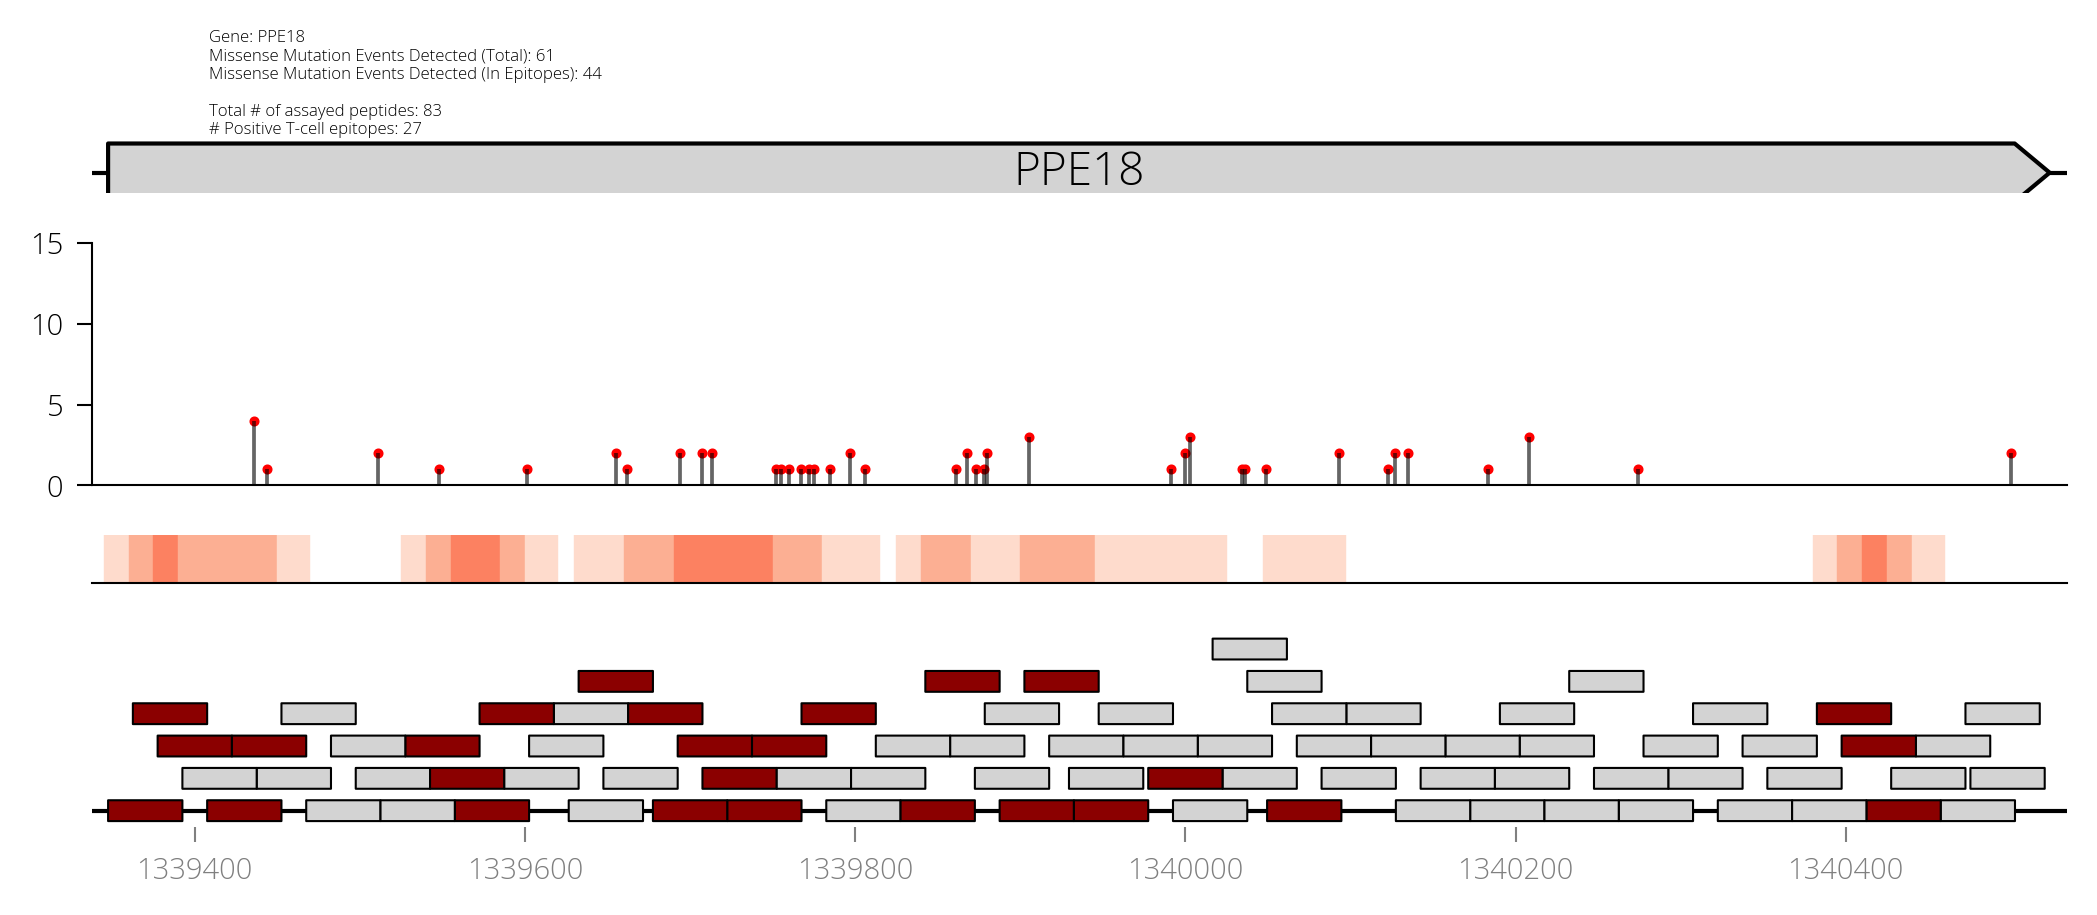

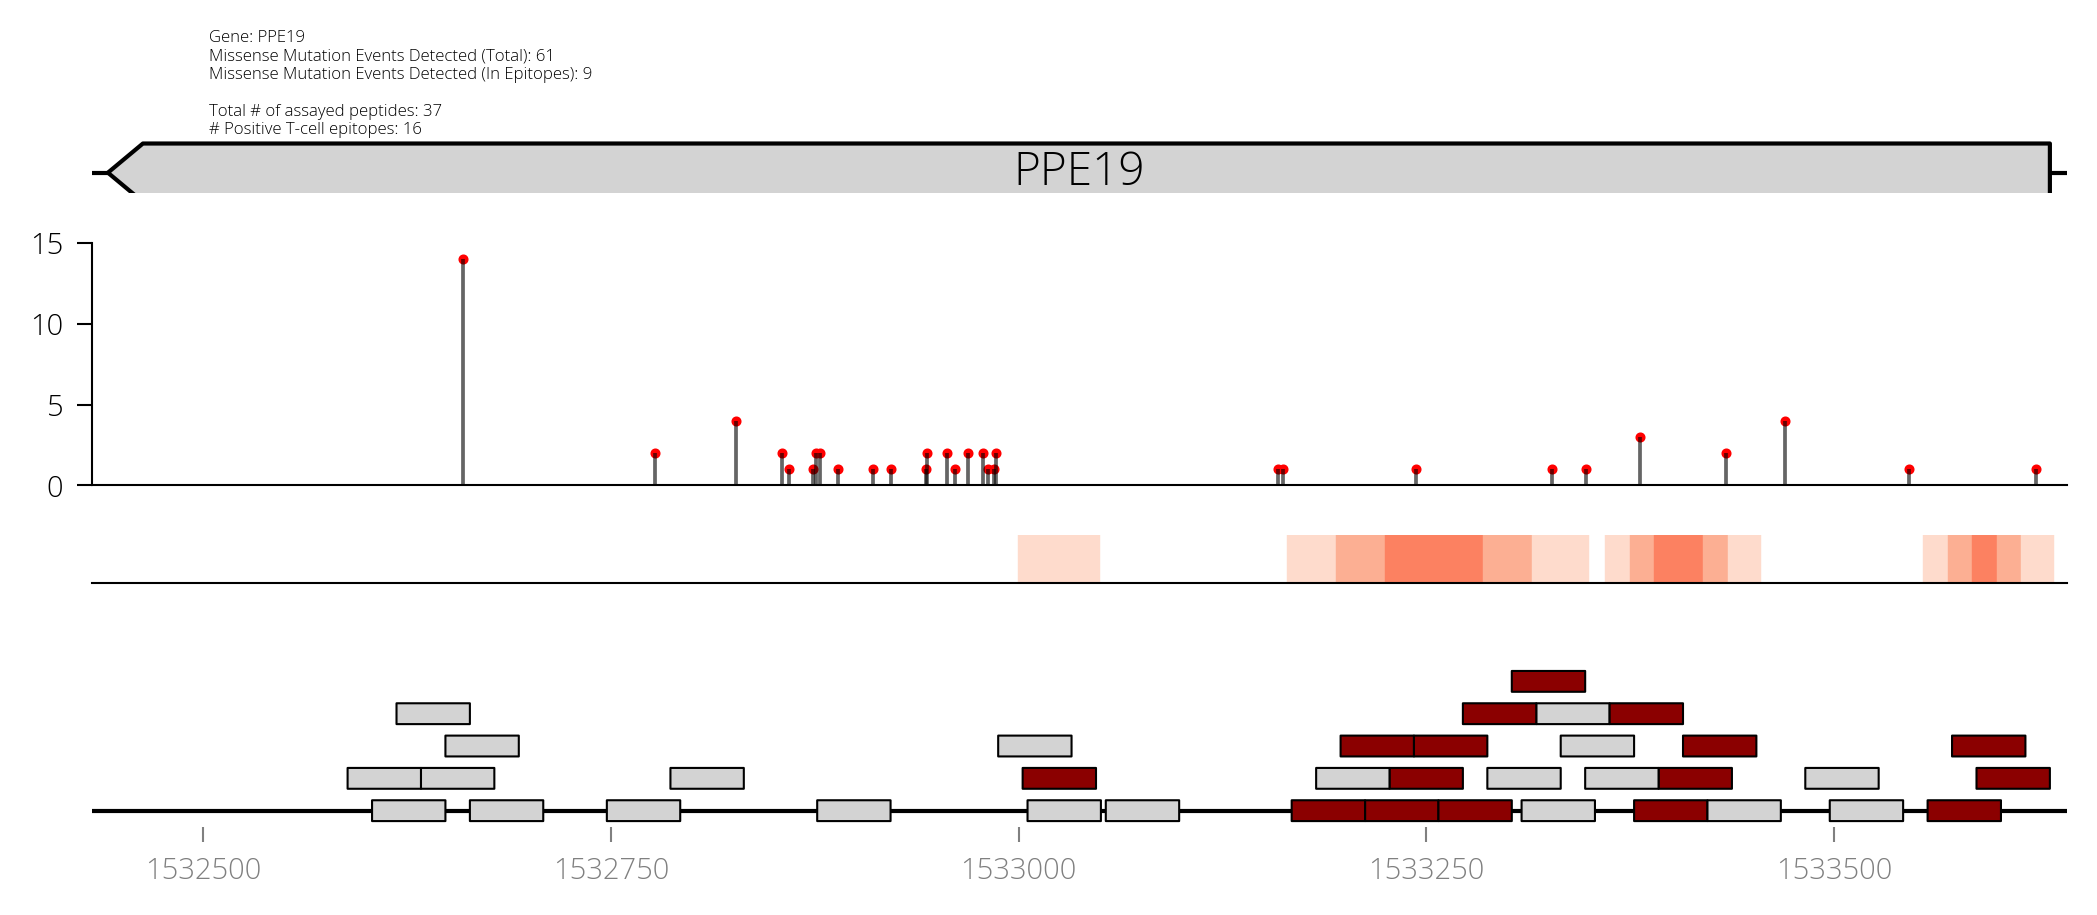

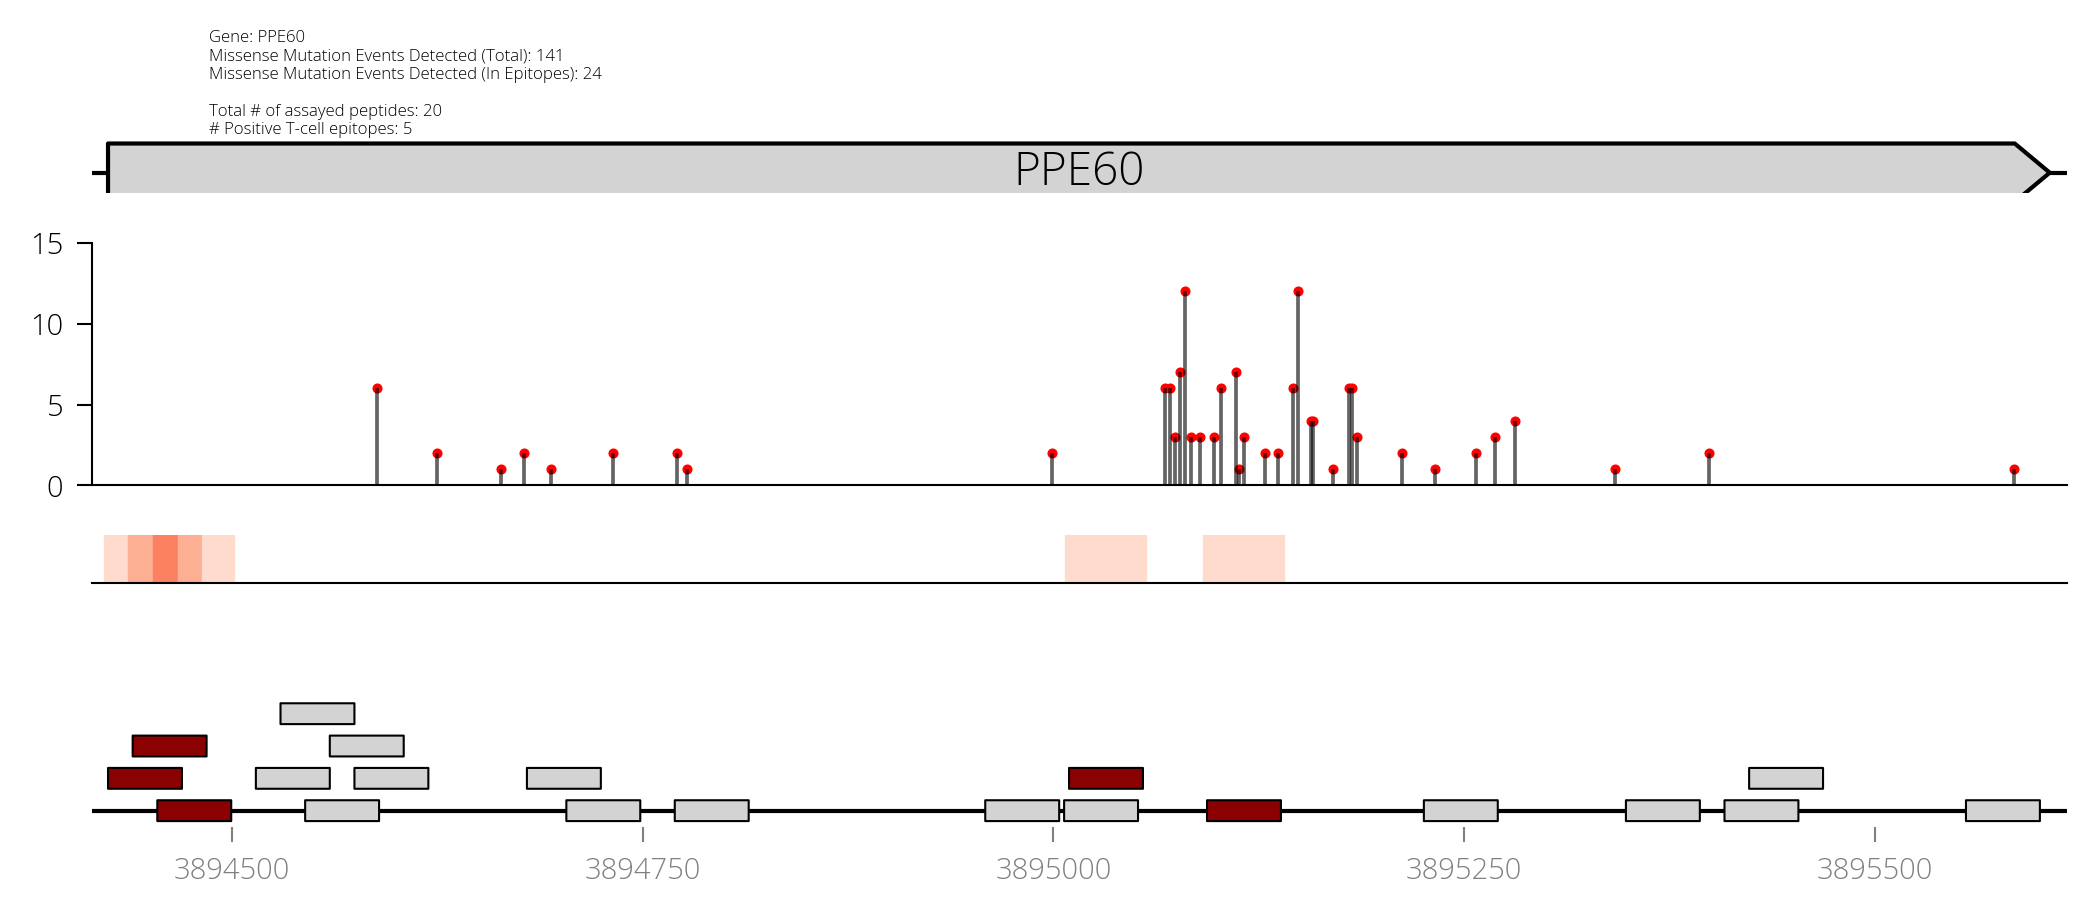

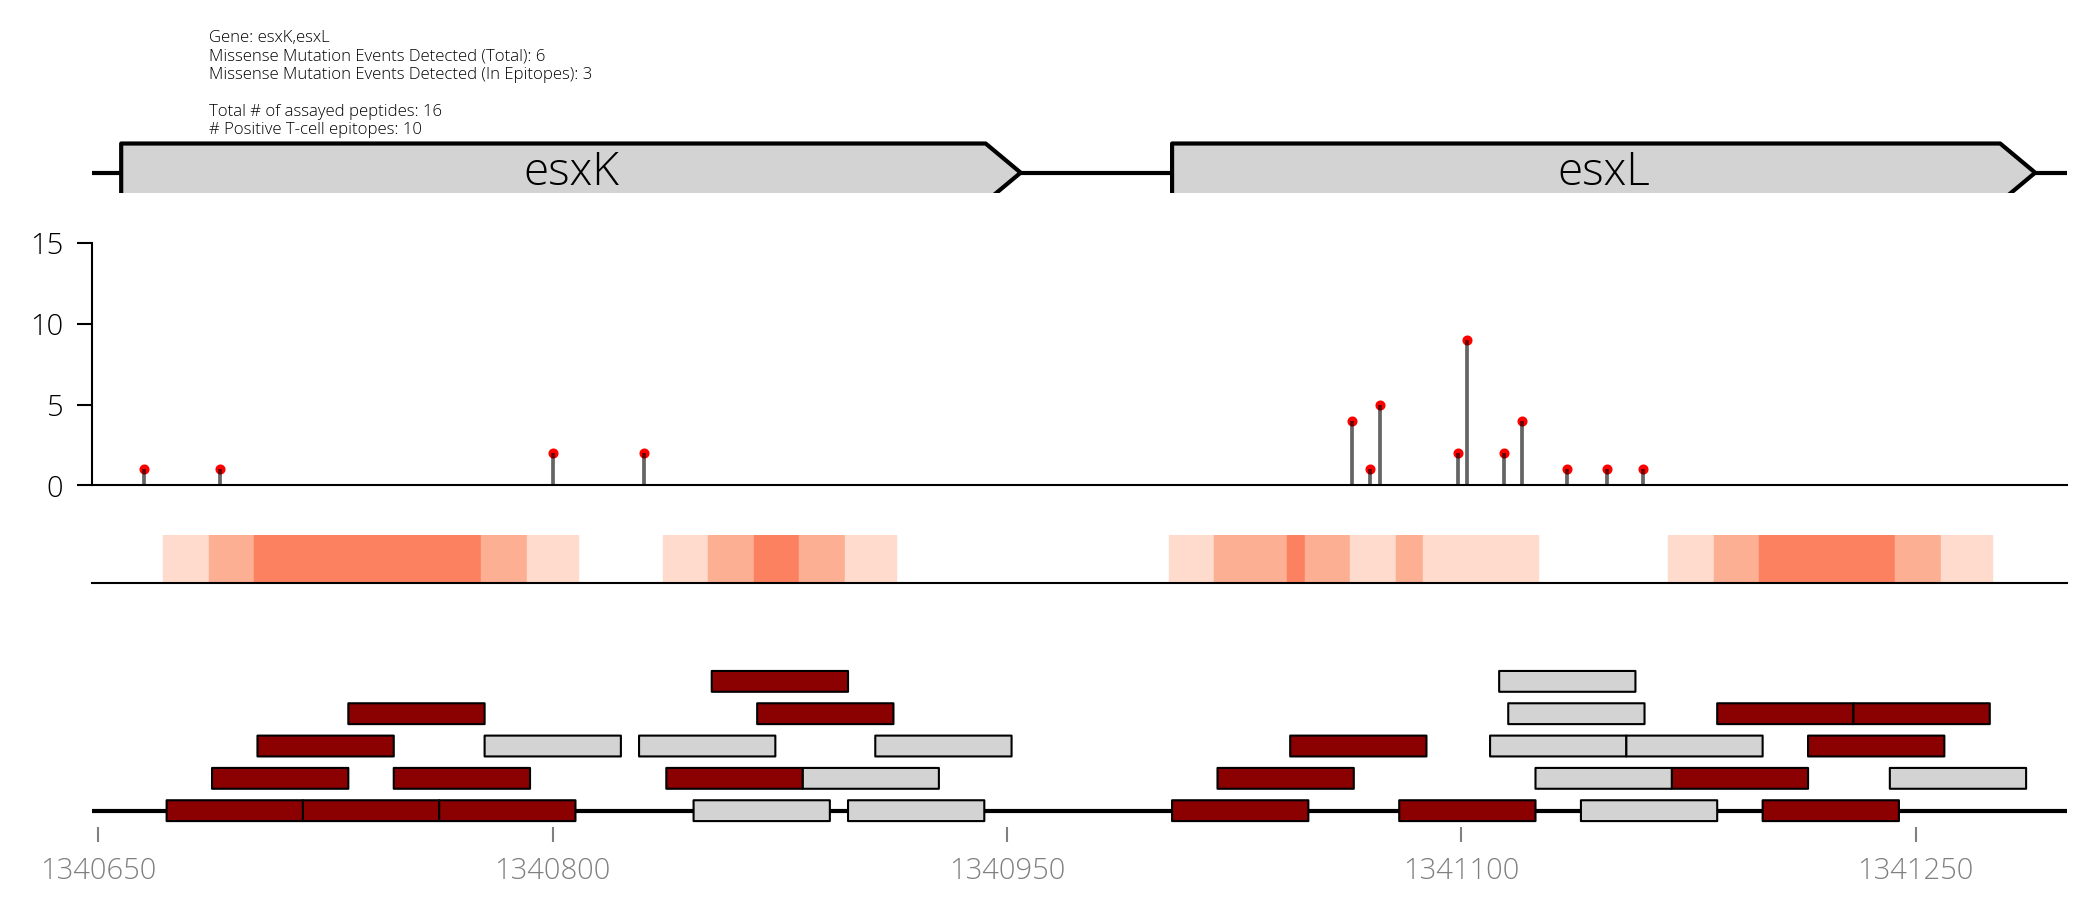

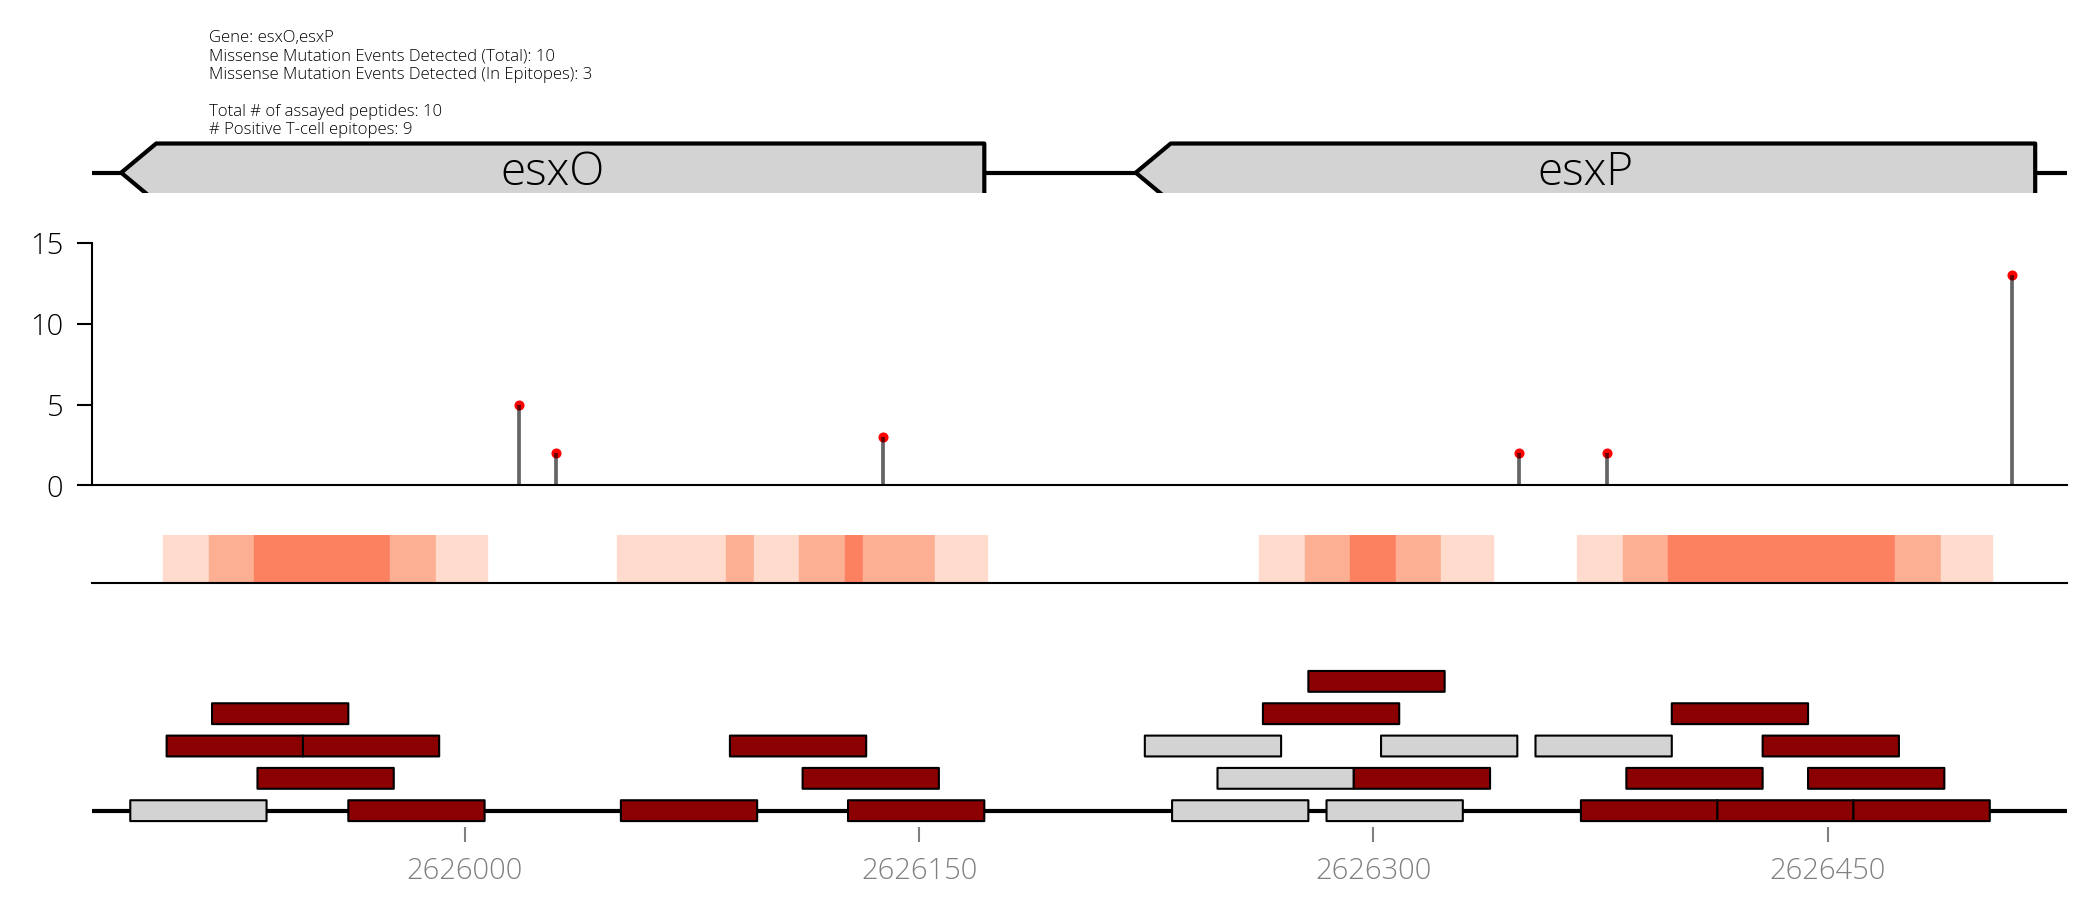

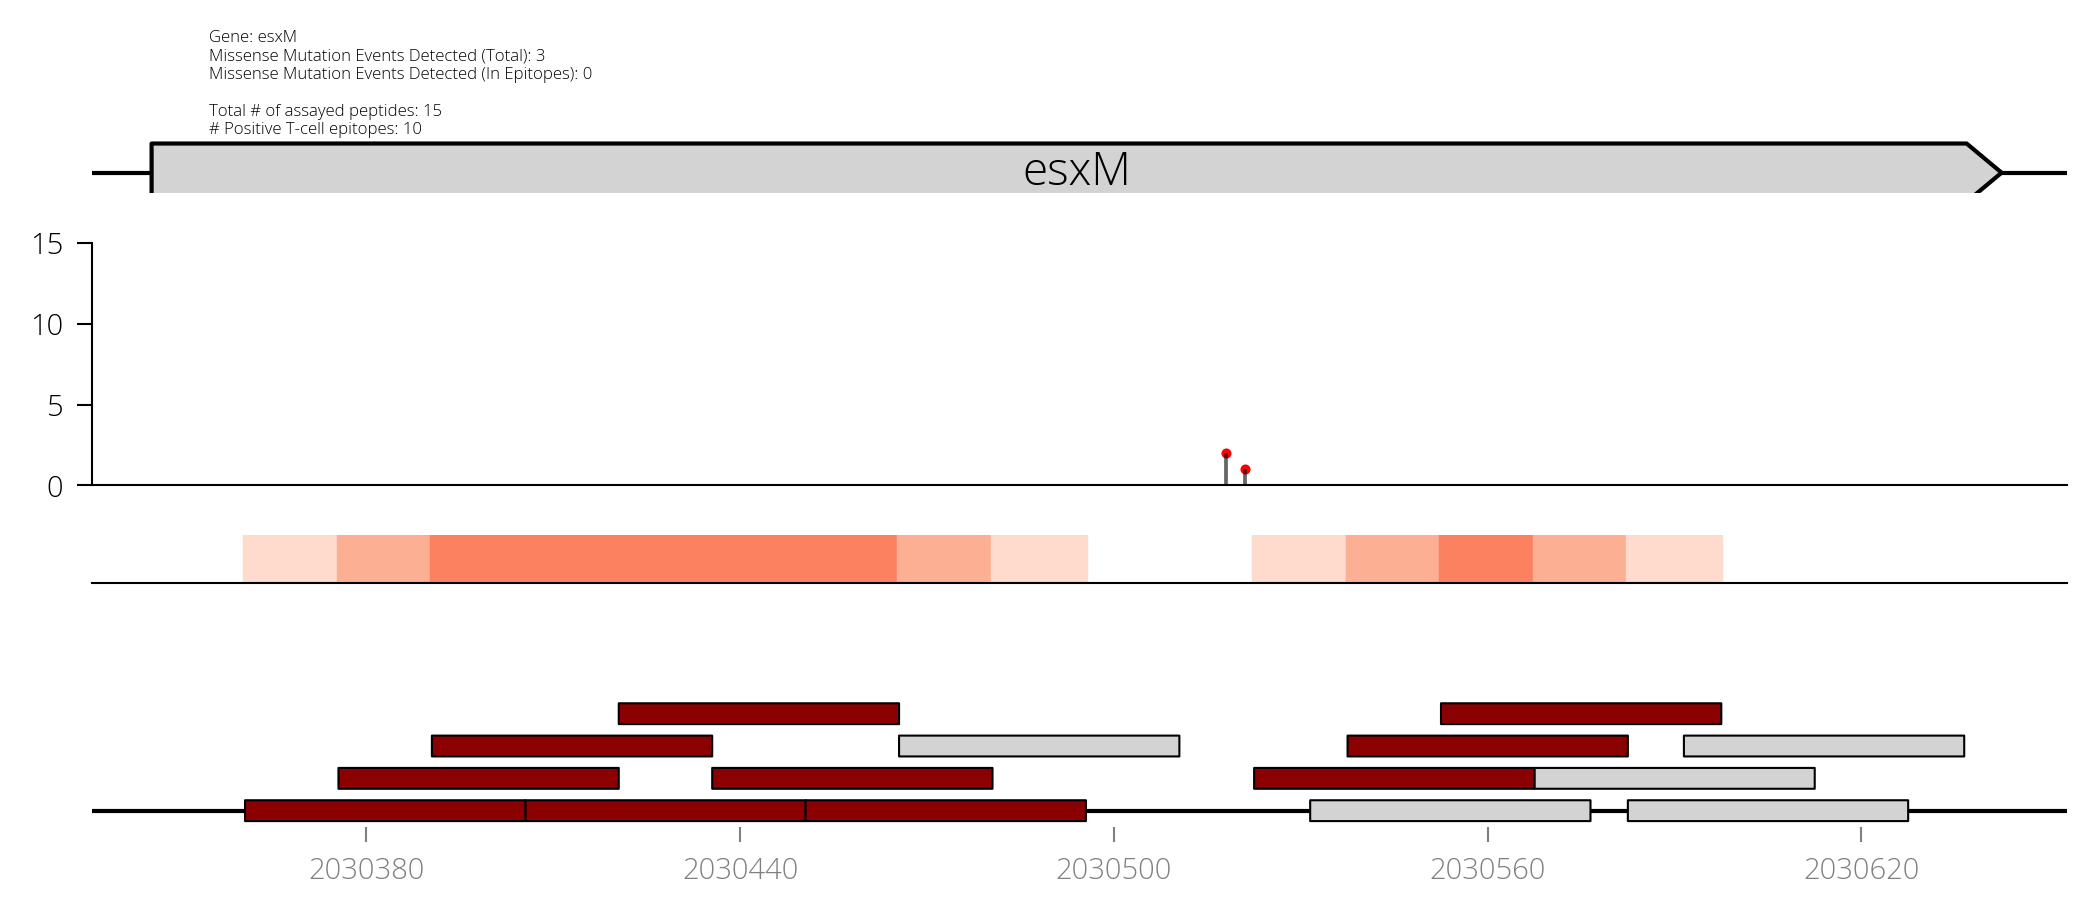

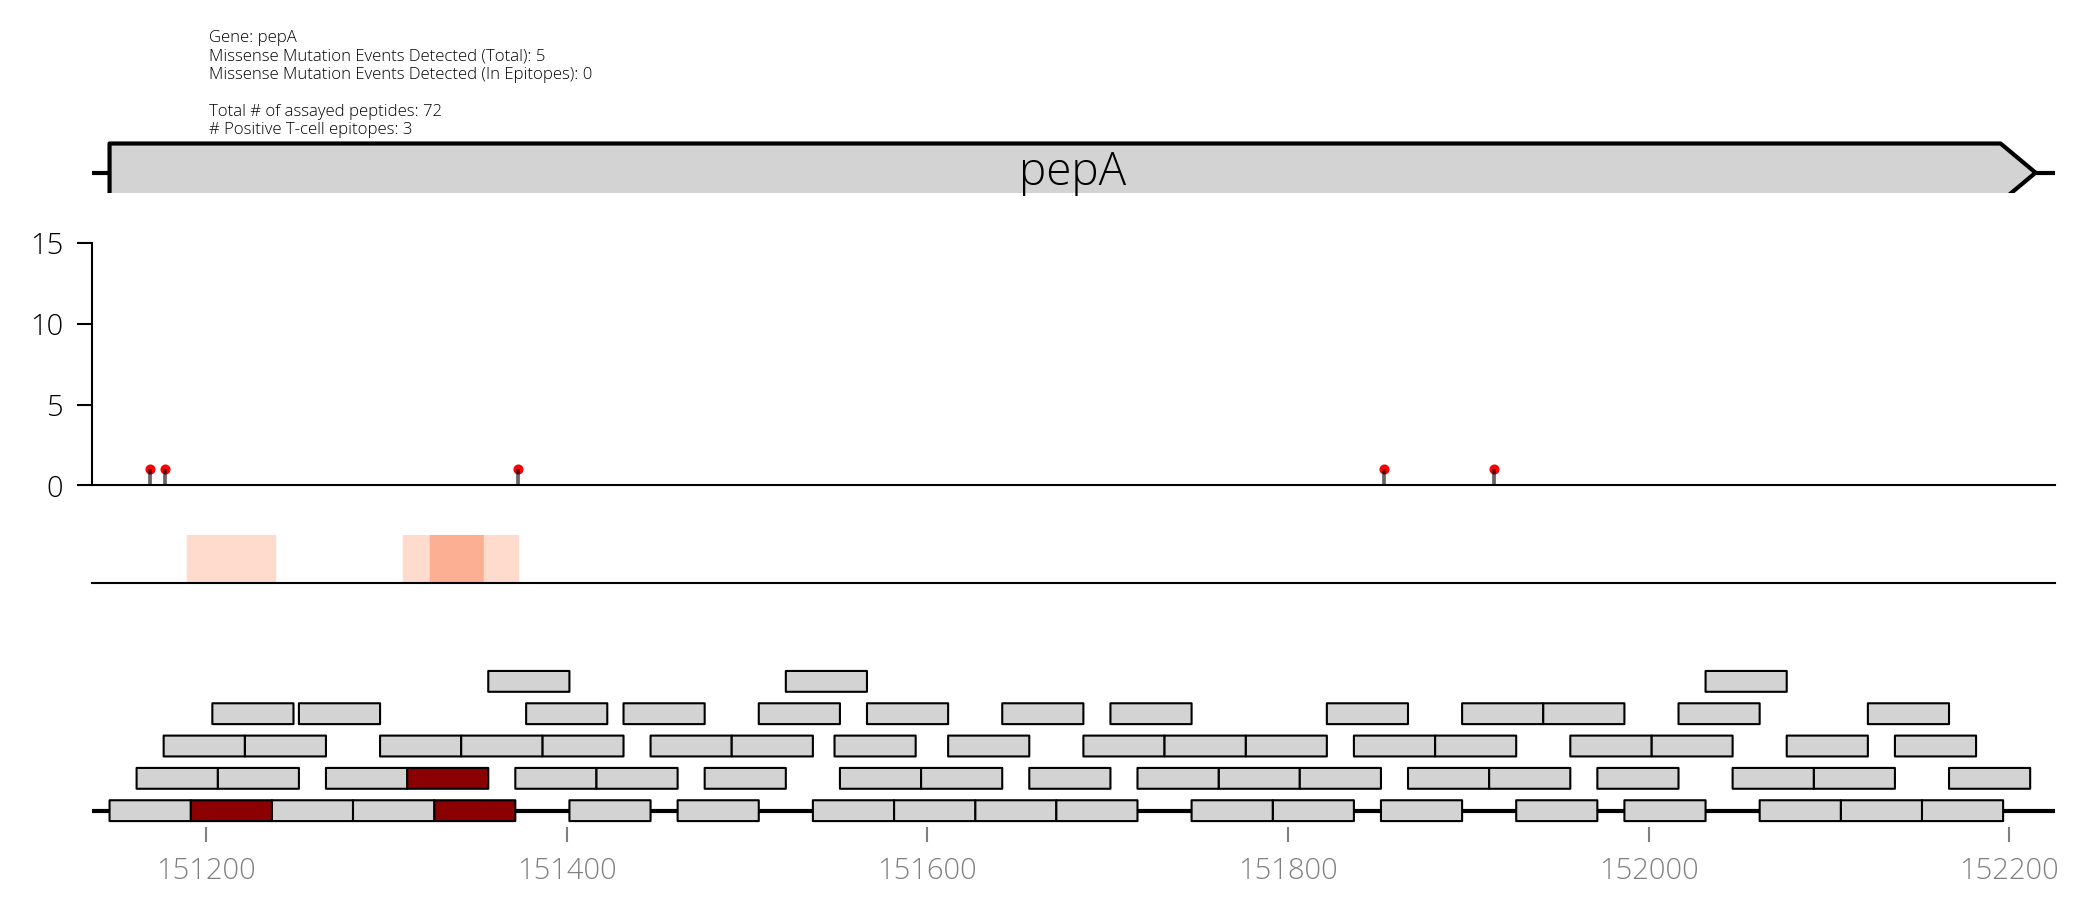

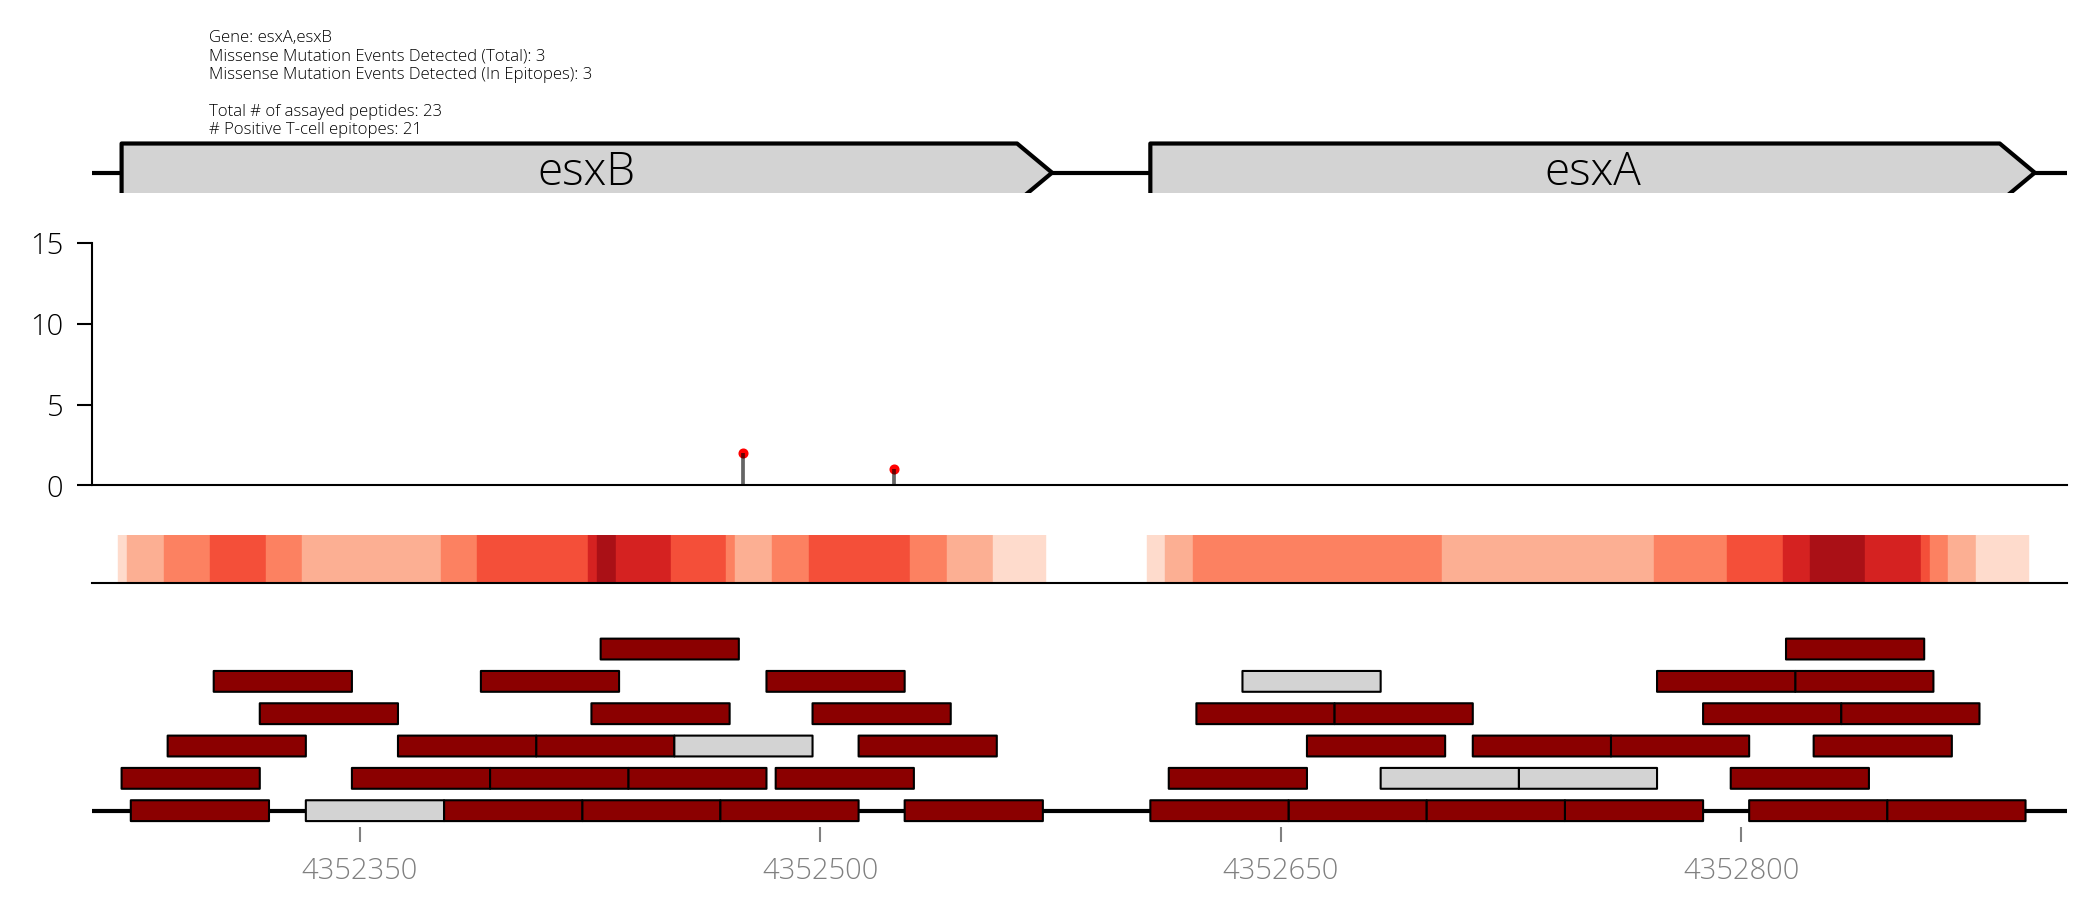

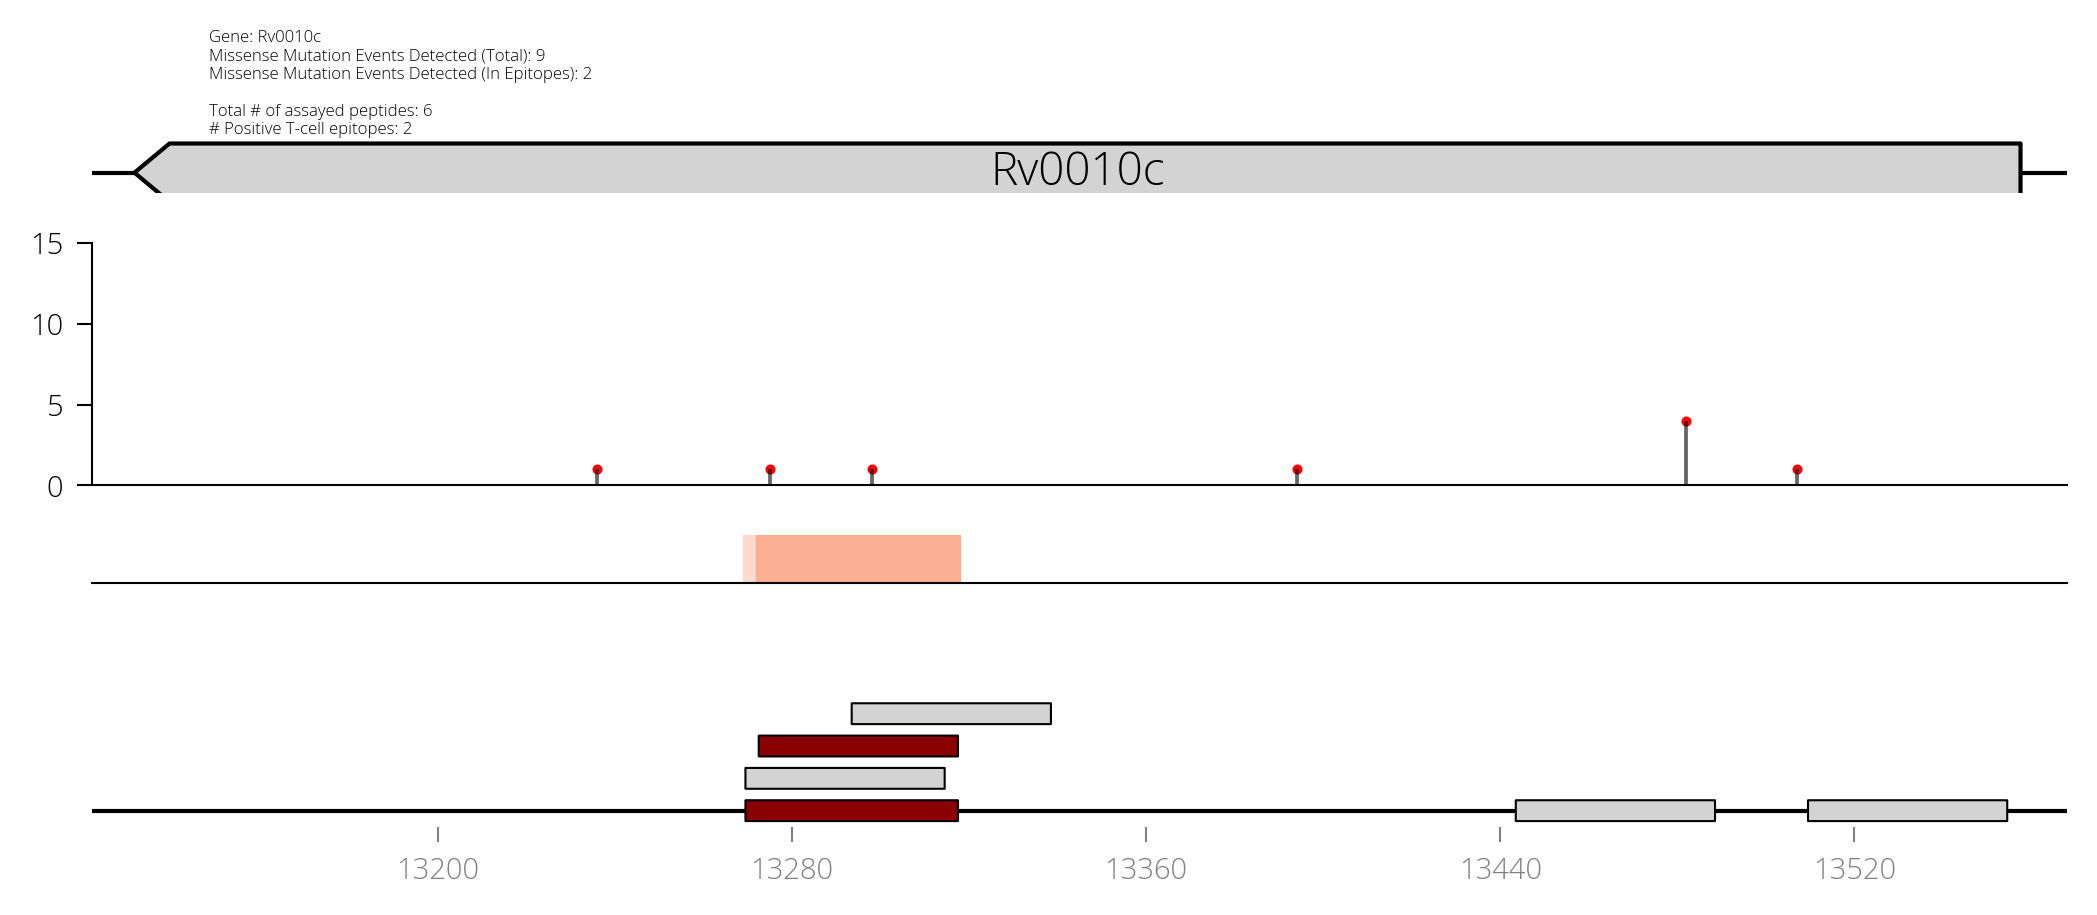

In [87]:
in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord

in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF


input_Antigen_Symbols = [ "PPE18", "PPE19", "PPE60", "esxK,esxL", "esxO,esxP",
                         "esxM", "pepA", "esxA,esxB", "Rv0010c", ]

#input_Antigen_Symbols = ["pepA", "esxA", "PPE18",]

for i_Symbol in input_Antigen_Symbols:


    i_Symbol_List = i_Symbol.split(",")
    i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF[  Genes_GCandMutFreqStats_DF["Symbol"].isin(i_Symbol_List) ]

    i_Gene_Start = i_Gene_MutInfo_DF["Start"].min()
    i_Gene_End = i_Gene_MutInfo_DF["End"].max()
    Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10
    
    i_N_Mut_Total = i_Gene_MutInfo_DF["Total_NS_Muts"].values[0]
    i_N_Mut_InEpitope = i_Gene_MutInfo_DF["Total_NS_Muts_InEpitope"].values[0]

    i_Gene_N_Epitopes = i_Gene_MutInfo_DF["N_Pos"].values[0]
    i_Gene_N_NegPeptide = i_Gene_MutInfo_DF["N_Neg"].values[0]
    i_Gene_N_PeptidesAssayed = i_Gene_MutInfo_DF["Total"].values[0]

    i_Gene_InHHR = i_Gene_MutInfo_DF["HasHmRegion"].values[0]

    GeneInfo_StrList = []
    GeneInfo_StrList.append( "Gene: " + i_Symbol)
    GeneInfo_StrList.append( "Missense Mutation Events Detected (Total): " + str(int(i_N_Mut_Total))   )
    GeneInfo_StrList.append( "Missense Mutation Events Detected (In Epitopes): " +  str(int(i_N_Mut_InEpitope))  )
    GeneInfo_StrList.append("")
    GeneInfo_StrList.append( "Total # of assayed peptides: " +  str(int(i_Gene_N_PeptidesAssayed)) )
    GeneInfo_StrList.append( "# Positive T-cell epitopes: " +  str(int(i_Gene_N_Epitopes))  )
    #GeneInfo_StrList.append( "# Negative peptides (non-reactive): " +  str(int(i_Gene_N_NegPeptide))  )

    print("\n".join(GeneInfo_StrList))
    print("\n")

    i_GEM_fig, i_GEM_axes = plot_Anno_Epitope_MutFreq(Viz_Start = Viz_Start, Viz_End = Viz_End,
                                                   in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF,
                                                   in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
                                                   in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord,
                                                   in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF,
                                                   mut_ylim=(0, 15),)

    i_GEM_fig.text(0.1, 0.87, "\n".join(GeneInfo_StrList), fontsize=4)


    i_GEM_fig.savefig(f"GeneViz_EpitopeAndNSMutFreq_Plots/{i_Symbol}.EpitopeAndNSMutFreq.V2.svg")
    
    i_GEM_fig.show()



# Part 2: Plot `genes` + `epitopes`  + `Mutation-Freq` -  Top `HHR-Antigens`

In [88]:
pGCE_DF.shape

(324, 50)

In [89]:
Gub_SNPs_V2_DF.shape

(26508, 24)

## Make plots - `Gene-Epitopes-Mutations-GCEs` plots for just PPE18 (HHR Antigens of highest interest)

In [90]:
!mkdir ./GeneViz_EpitopeMutsGCEs_PPE18_Plots/

mkdir: cannot create directory ‘./GeneViz_EpitopeMutsGCEs_PPE18_Plots/’: File exists


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:410: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz

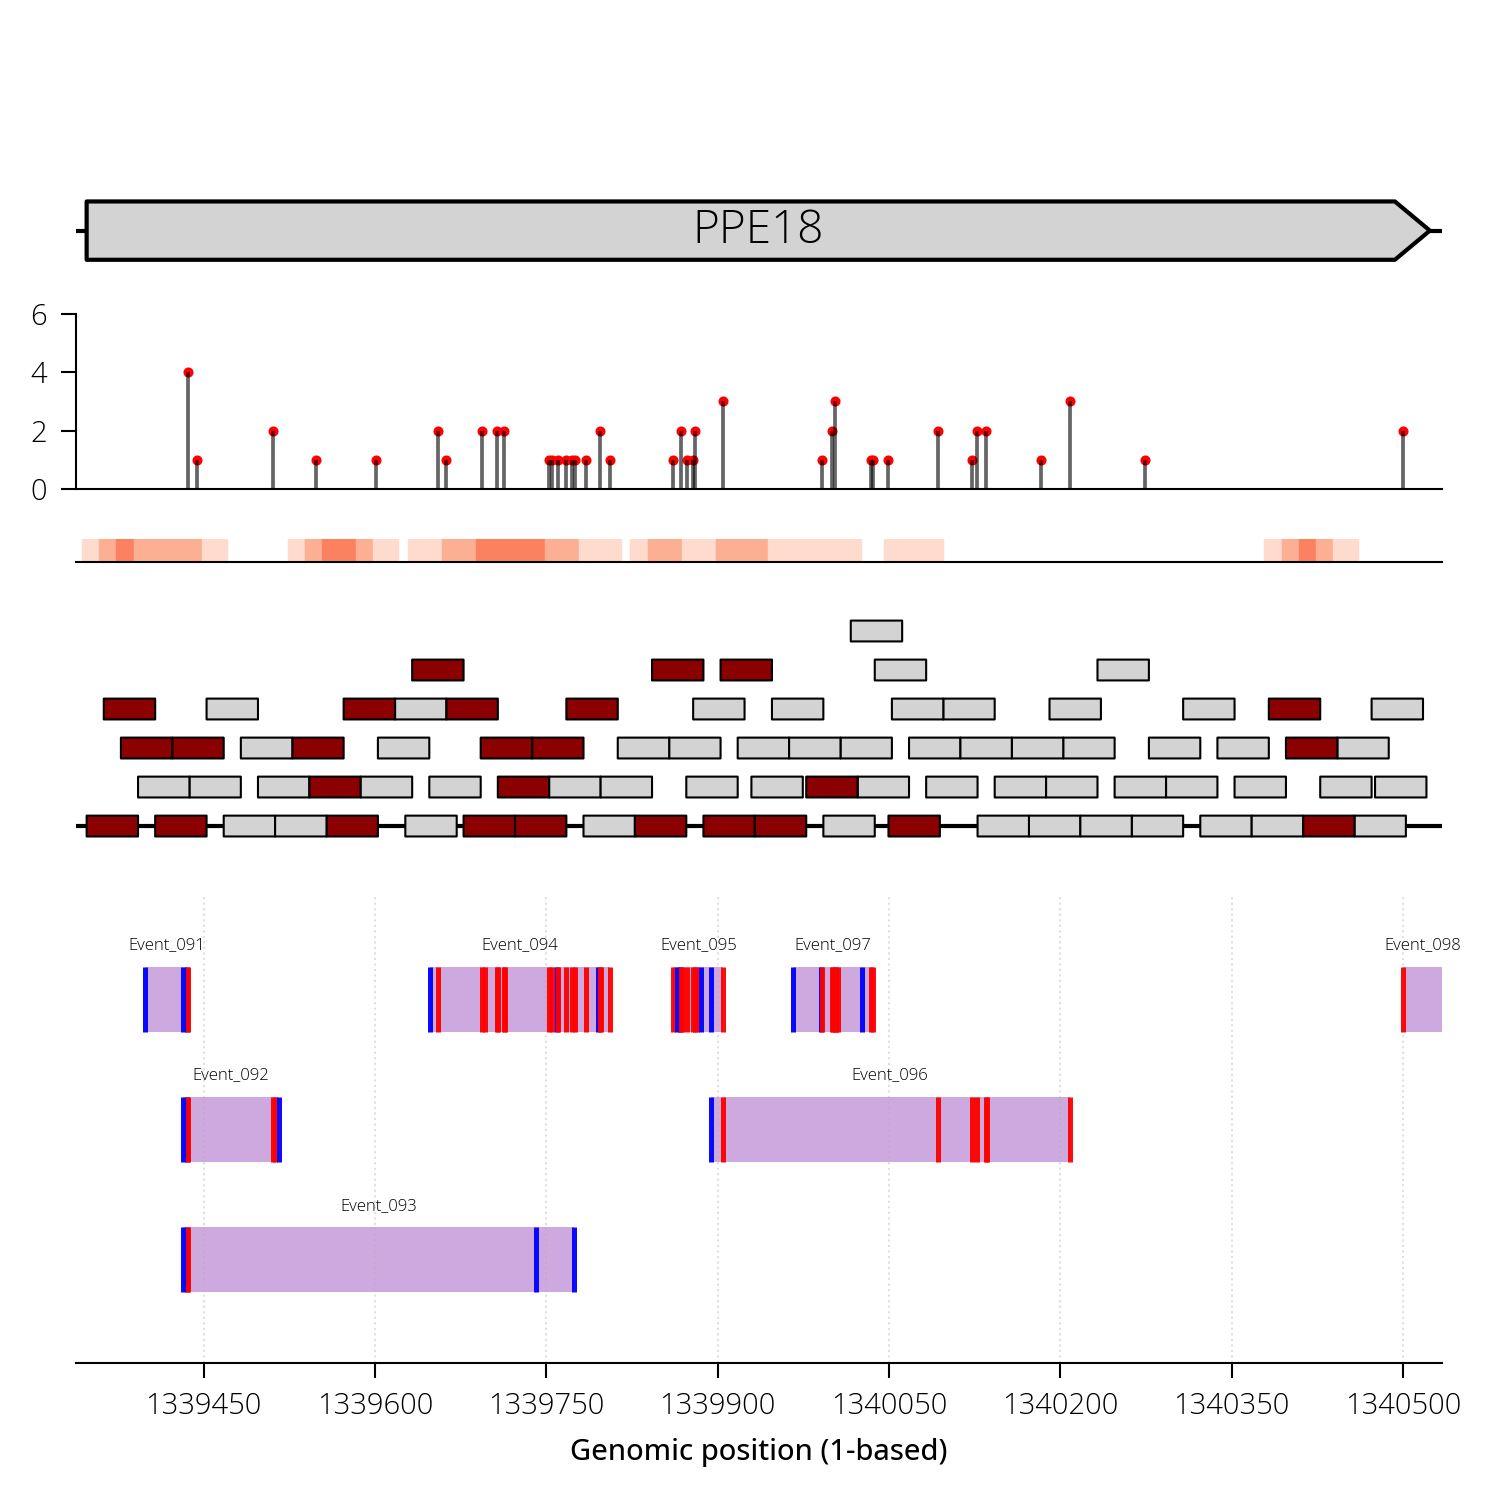

In [91]:
in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord

in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF


input_Antigen_Symbols = ["PPE18",]


for i_Symbol in input_Antigen_Symbols:

    i_Symbol_List = i_Symbol.split(",")
    i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF[  Genes_GCandMutFreqStats_DF["Symbol"].isin(i_Symbol_List) ]

    i_Gene_Start = i_Gene_MutInfo_DF["Start"].min()
    i_Gene_End = i_Gene_MutInfo_DF["End"].max()
    
    Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10
    
    i_N_Mut_Total = i_Gene_MutInfo_DF["Total_NS_Muts"].values[0]
    i_N_Mut_InEpitope = i_Gene_MutInfo_DF["Total_NS_Muts_InEpitope"].values[0]

    i_Gene_N_Epitopes = i_Gene_MutInfo_DF["N_Pos"].values[0]
    i_Gene_N_NegPeptide = i_Gene_MutInfo_DF["N_Neg"].values[0]
    i_Gene_N_PeptidesAssayed = i_Gene_MutInfo_DF["Total"].values[0]

    i_Gene_InHHR = i_Gene_MutInfo_DF["HasHmRegion"].values[0]


    i_GEMG_fig, i_GEMG_axes = plot_mut_epitope_region_with_gce_V2(Viz_Start = Viz_Start, Viz_End = Viz_End,
                                                        in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF,
                                                        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
                                                        in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord,
                                                        in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF,
                                                        pGCE_df = pGCE_DF,
                                                        snps_df = Gub_SNPs_V2_DF,
                                                        gce_label_fontsize = 4,
                                                        mut_ylim=(0, 6),
                                                        height_ratios = (4, 3, 0.4, 4, 8),
                                                        )


    i_GEMG_fig.savefig(f"GeneViz_EpitopeMutsGCEs_PPE18_Plots/{i_Symbol}.Epitopes.NSMutFreq.GCEs.V2.svg")
    
    i_GEMG_fig.show()



## Make plots - `Gene-Epitopes-Mutations-GCEs` plots for top HHR Antigens

In [99]:
!mkdir ./GeneViz_EpitopeMutsGCEs_Plots/

mkdir: cannot create directory ‘./GeneViz_EpitopeMutsGCEs_Plots/’: File exists


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:410: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz

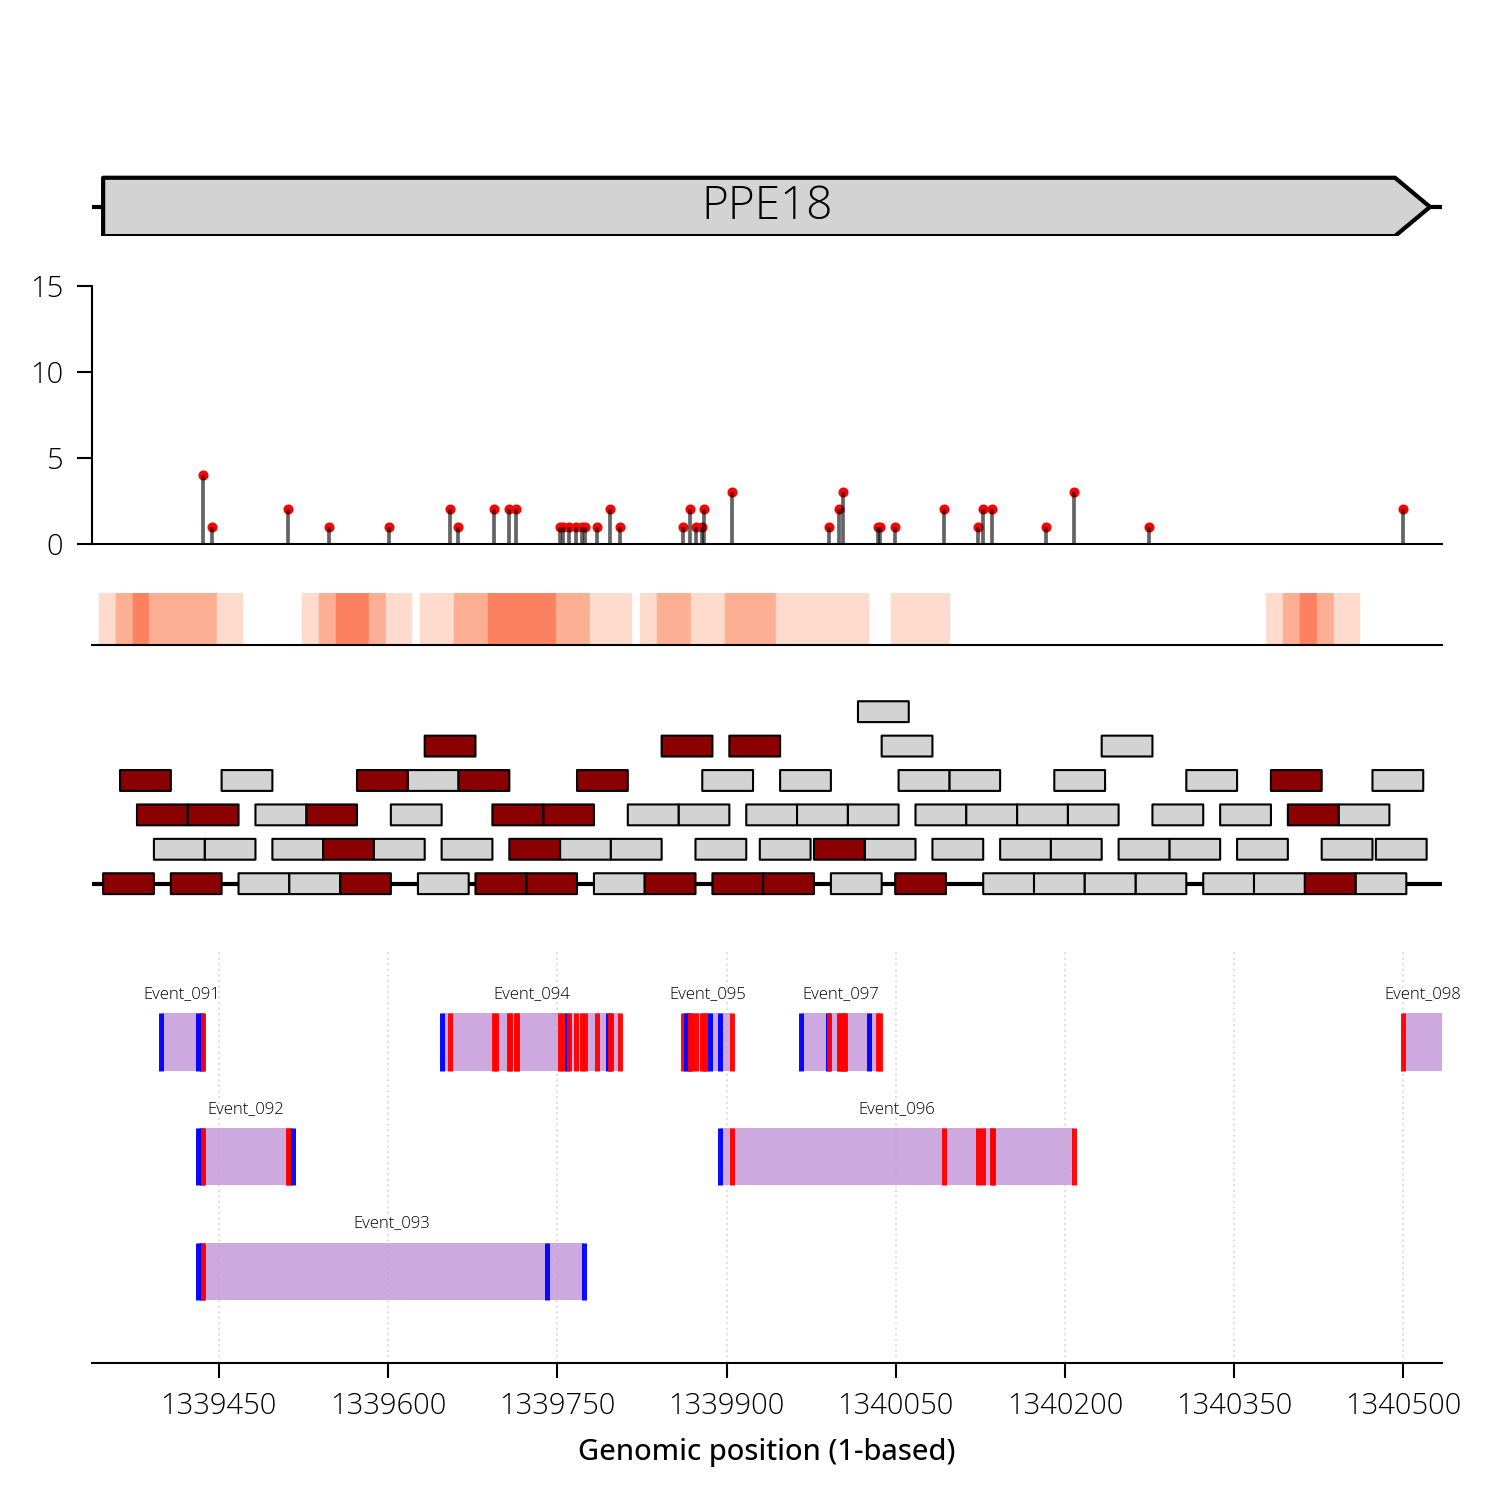

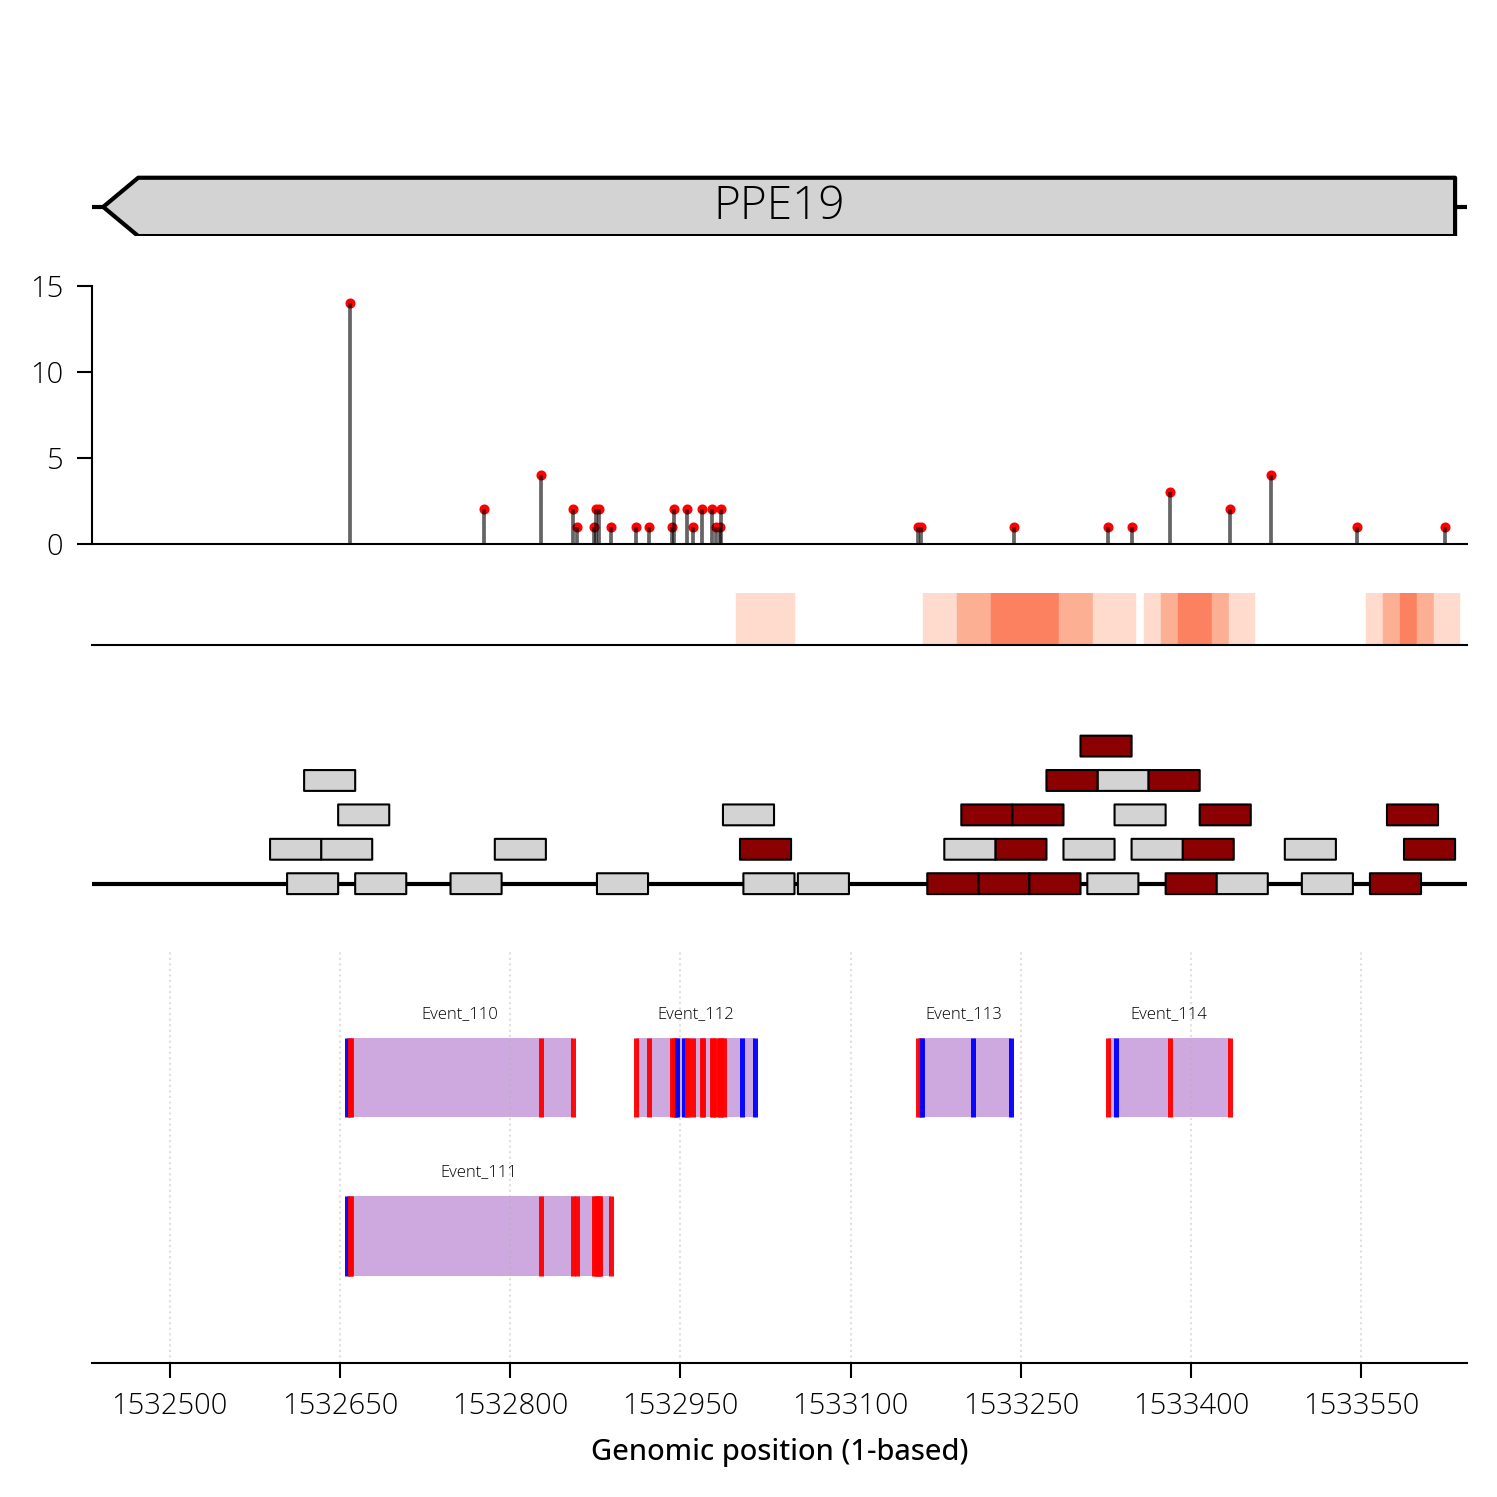

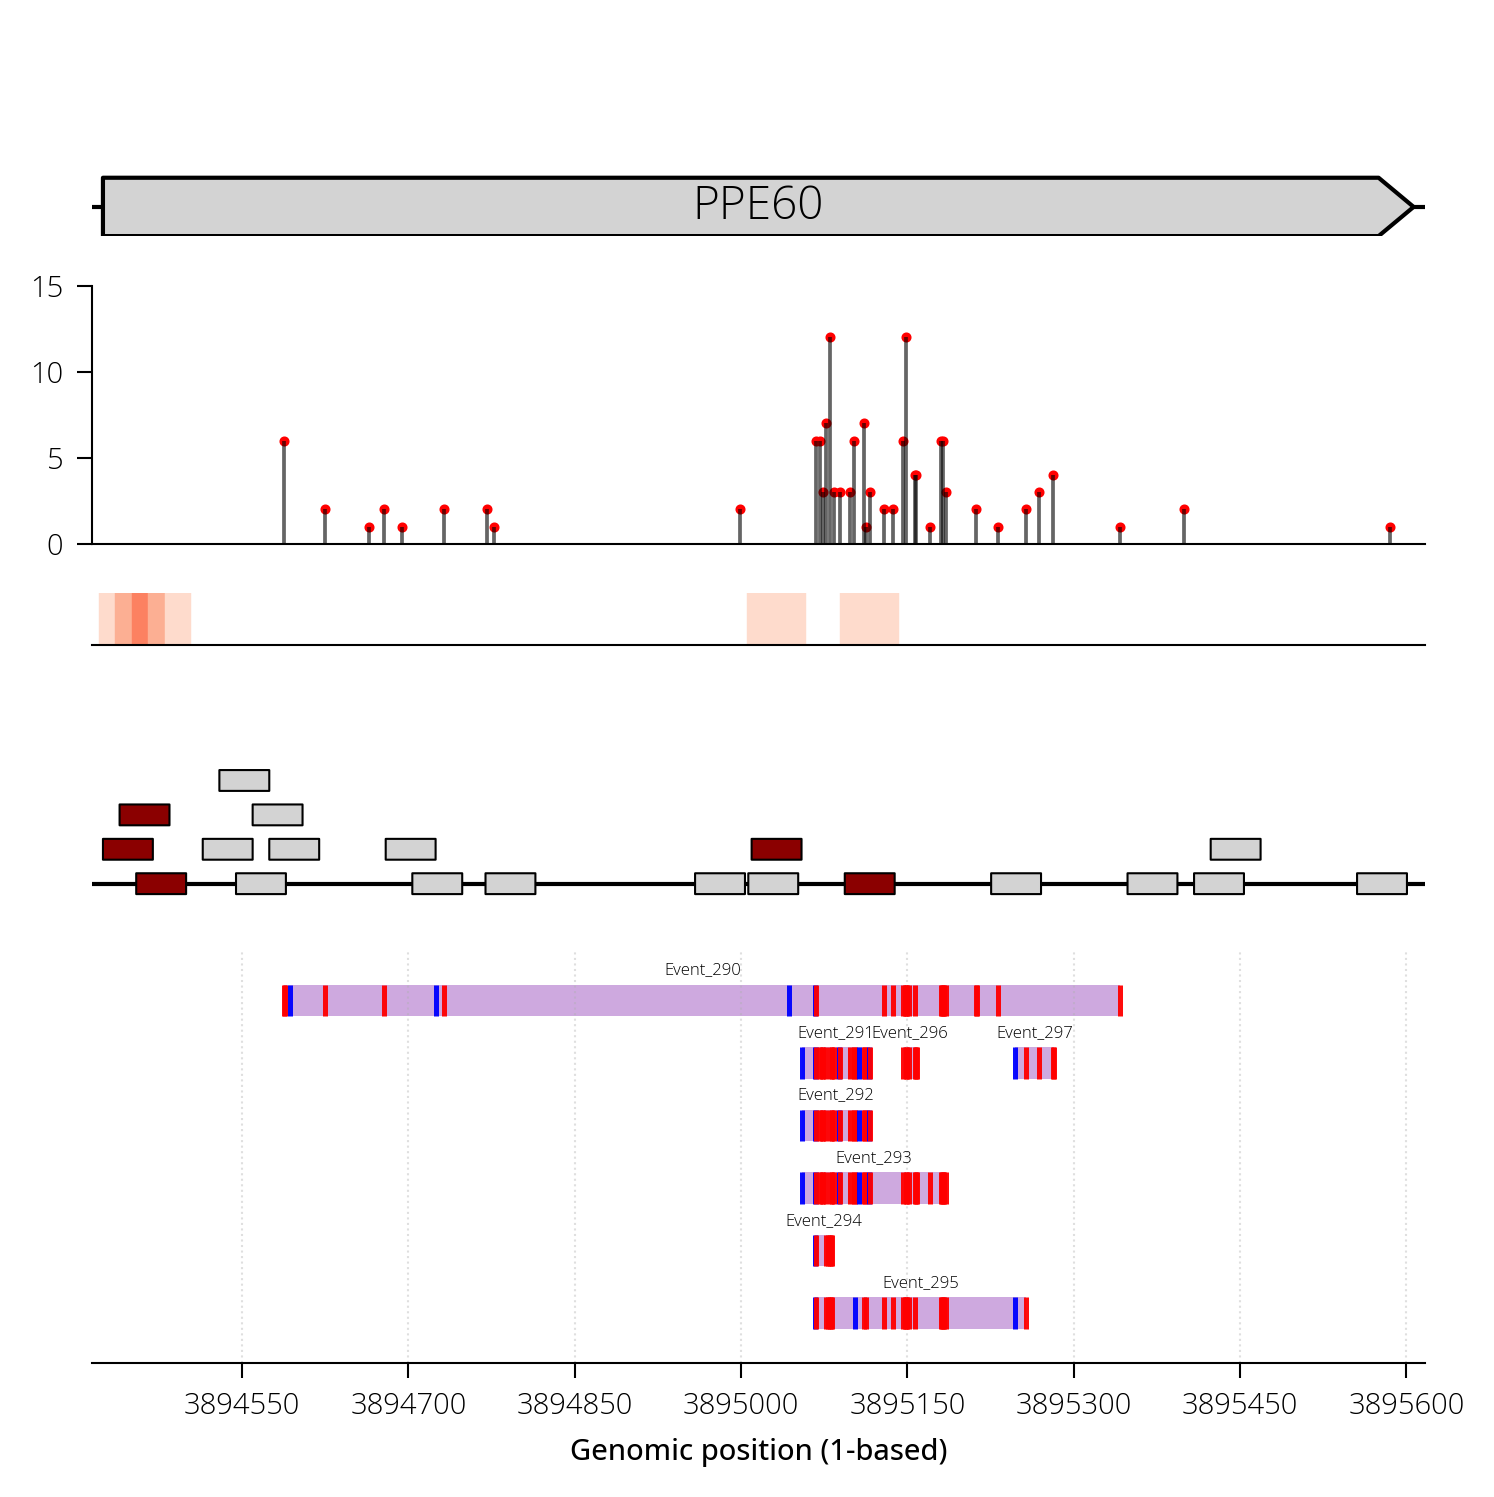

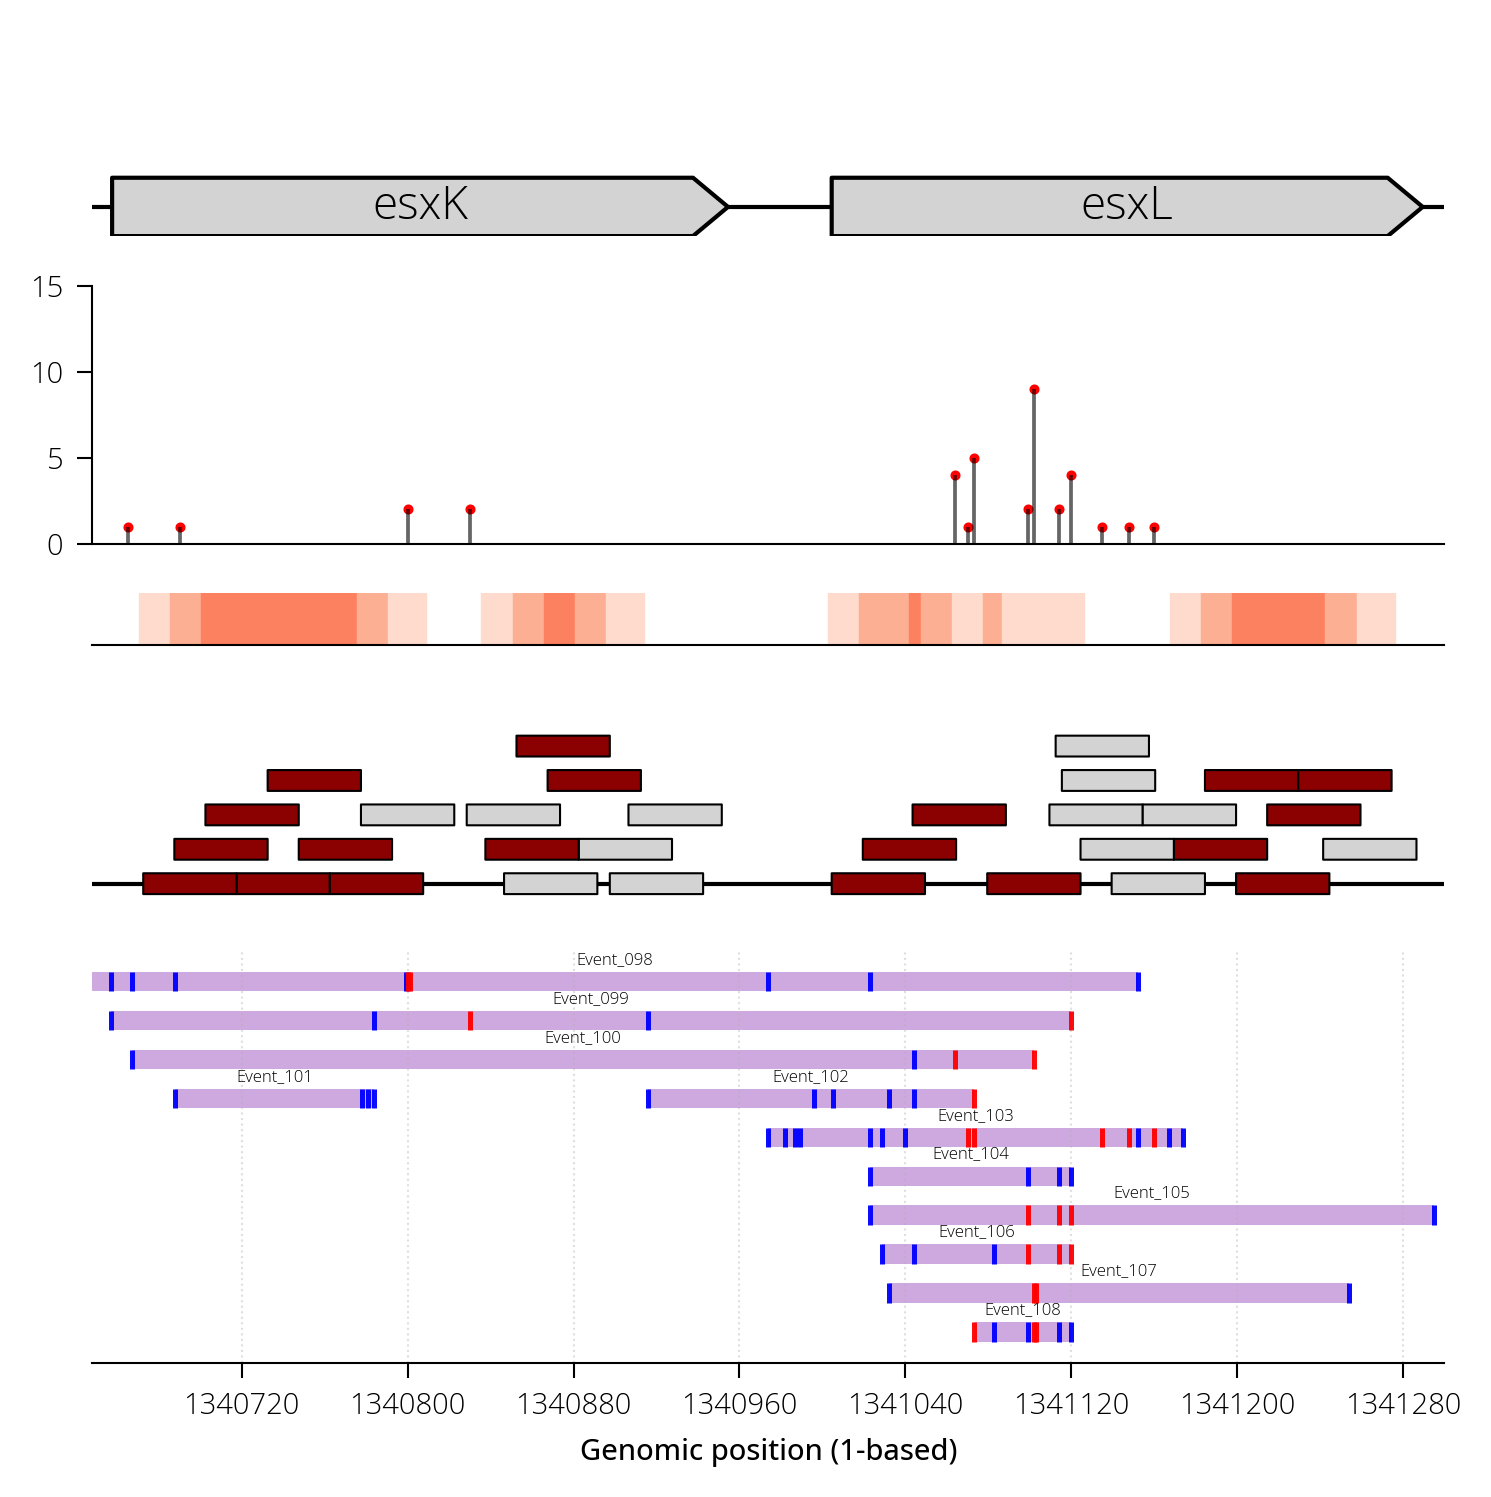

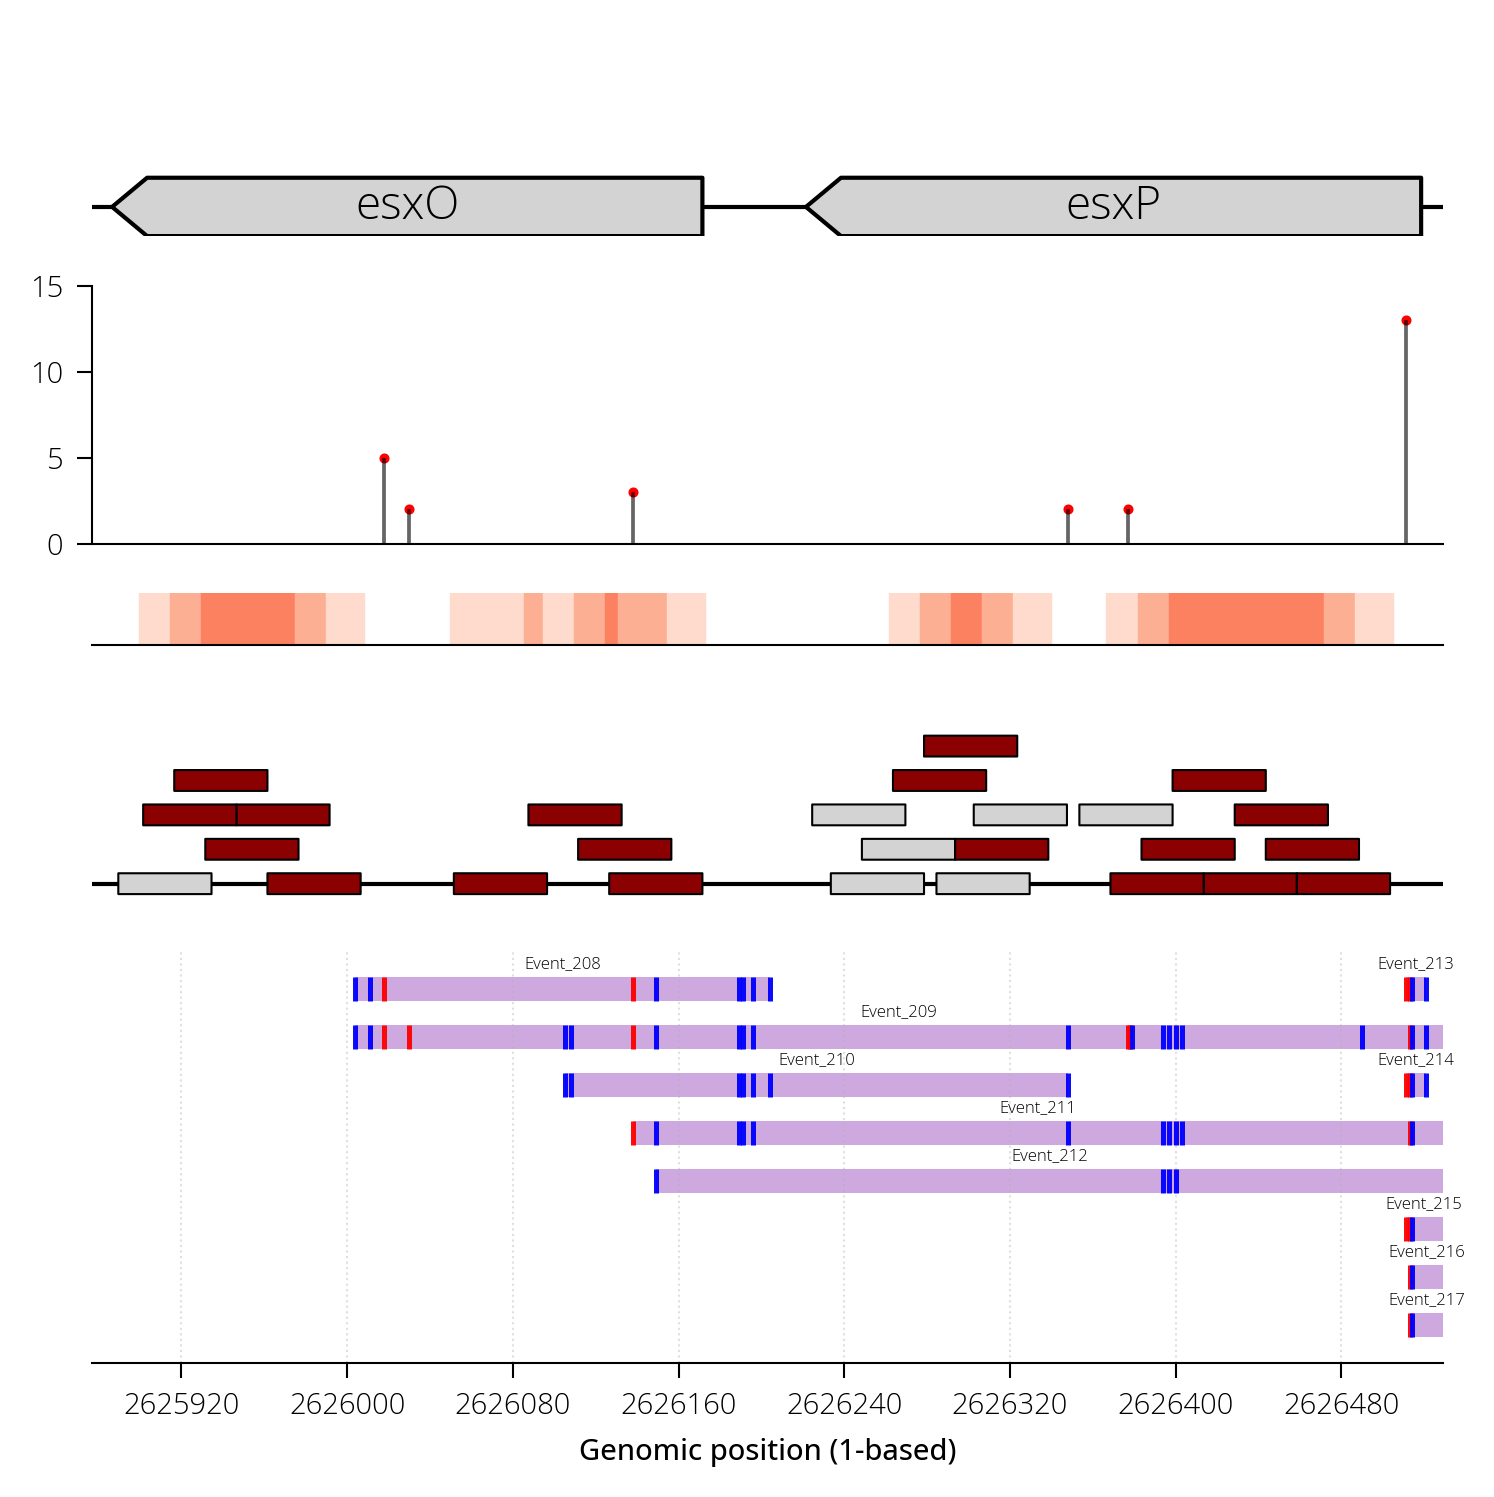

In [100]:
in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord

in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF


input_Antigen_Symbols = ["PPE18", "PPE19", "PPE60",
                         "esxL,esxK", "esxO,esxP",]


for i_Symbol in input_Antigen_Symbols:

    i_Symbol_List = i_Symbol.split(",")
    i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF[  Genes_GCandMutFreqStats_DF["Symbol"].isin(i_Symbol_List) ]

    i_Gene_Start = i_Gene_MutInfo_DF["Start"].min()
    i_Gene_End = i_Gene_MutInfo_DF["End"].max()
    
    Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10
    
    i_N_Mut_Total = i_Gene_MutInfo_DF["Total_NS_Muts"].values[0]
    i_N_Mut_InEpitope = i_Gene_MutInfo_DF["Total_NS_Muts_InEpitope"].values[0]

    i_Gene_N_Epitopes = i_Gene_MutInfo_DF["N_Pos"].values[0]
    i_Gene_N_NegPeptide = i_Gene_MutInfo_DF["N_Neg"].values[0]
    i_Gene_N_PeptidesAssayed = i_Gene_MutInfo_DF["Total"].values[0]

    i_Gene_InHHR = i_Gene_MutInfo_DF["HasHmRegion"].values[0]


    i_GEMG_fig, i_GEMG_axes = plot_mut_epitope_region_with_gce_V2(Viz_Start = Viz_Start, Viz_End = Viz_End,
                                                        in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF,
                                                        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
                                                        in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord,
                                                        in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF,
                                                        pGCE_df = pGCE_DF,
                                                        snps_df = Gub_SNPs_V2_DF,
                                                        gce_label_fontsize = 4,
                                                        mut_ylim=(0, 15),)


    i_GEMG_fig.savefig(f"GeneViz_EpitopeMutsGCEs_Plots/{i_Symbol}.Epitopes.NSMutFreq.GCEs.V2.svg")
    
    i_GEMG_fig.show()



# Part X

# Plot all detected recomb events within a region of interest

## Viz all GCEs in `PPE18` 

PPE18
1339248 1340624


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:410: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz

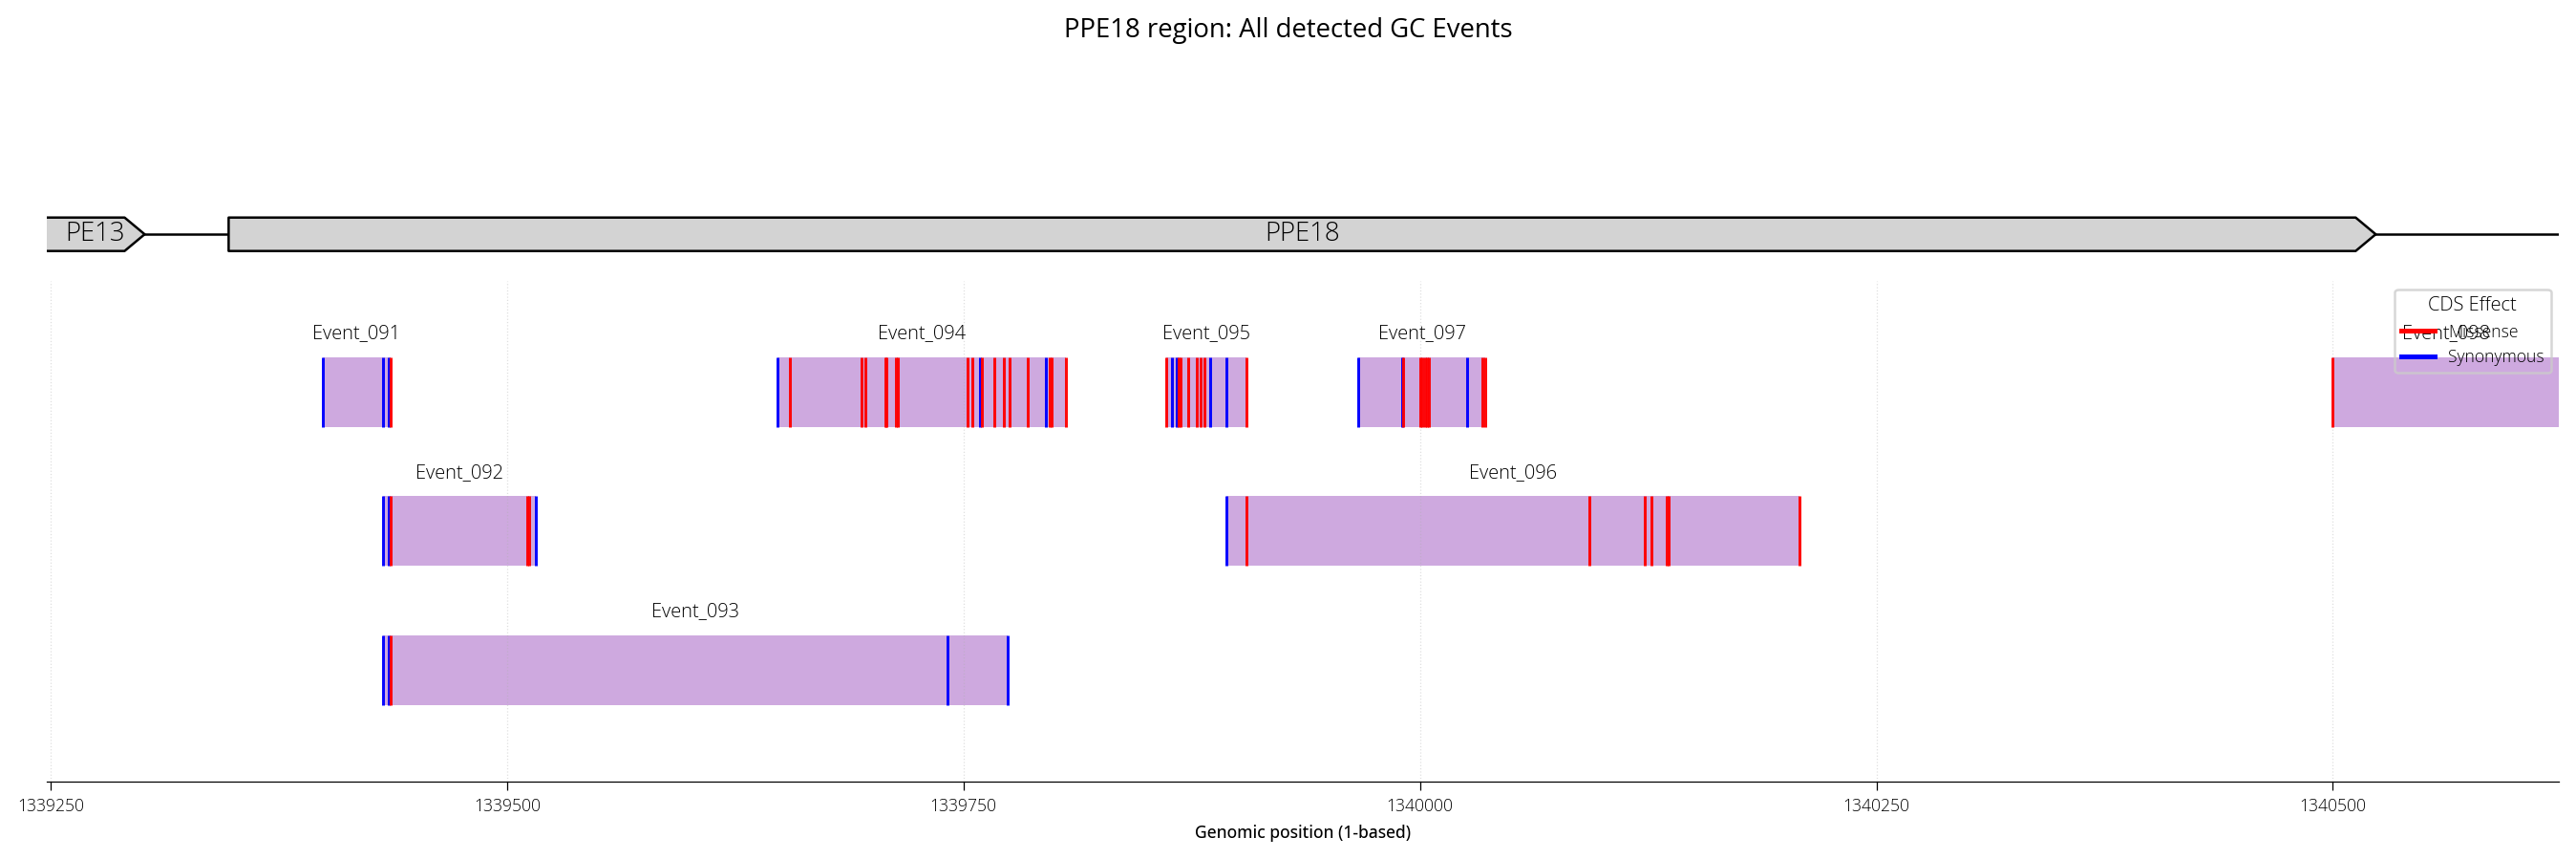

In [101]:
i_Symbol = "PPE18"

print(i_Symbol)

i_Symbol_List = i_Symbol.split(",")
GeneInfo_DF = Genes_GCandMutFreqStats_DF[  Genes_GCandMutFreqStats_DF["Symbol"].isin(i_Symbol_List) ]

i_Gene_Start = GeneInfo_DF["Start"].min()
i_End_Start = GeneInfo_DF["End"].max()
Viz_Start, Viz_End =  i_Gene_Start - 100 , i_End_Start + 100

print(Viz_Start, Viz_End)

# ------------------------
# Apply to PPE18 (1339338..1340534)
# ------------------------

fig4, ax4, = plot_Anno_with_GCE_V3(Viz_Start = Viz_Start,
                                   Viz_End = Viz_End,
                                   in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
                                   pGCE_df = pGCE_DF,
                                   snps_df = Gub_SNPs_V2_DF,
                                   title = f"{i_Symbol} region: All detected GC Events",
                                  )


## Make plots - `Gene + GCEs` plots for genomic regions around top Antigens

In [102]:
!mkdir ./GeneViz_WiGCEs_Plots/

mkdir: cannot create directory ‘./GeneViz_WiGCEs_Plots/’: File exists


In [103]:
Gub_SNPs_V2_DF.head(3)

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap,MissenseMut
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,lineage5,0,True
1,10321,Node_1,N1176,C,T,NaN,10320,NC_000962.3,0,0,Unq,1,Rv0007,+,407.0,136.0,3.0,NaN,NaN,10320,10321,lineage5,0,False
2,11846,Node_1,N1176,C,G,NaN,11845,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11845,11846,lineage5,0,False


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:410: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz

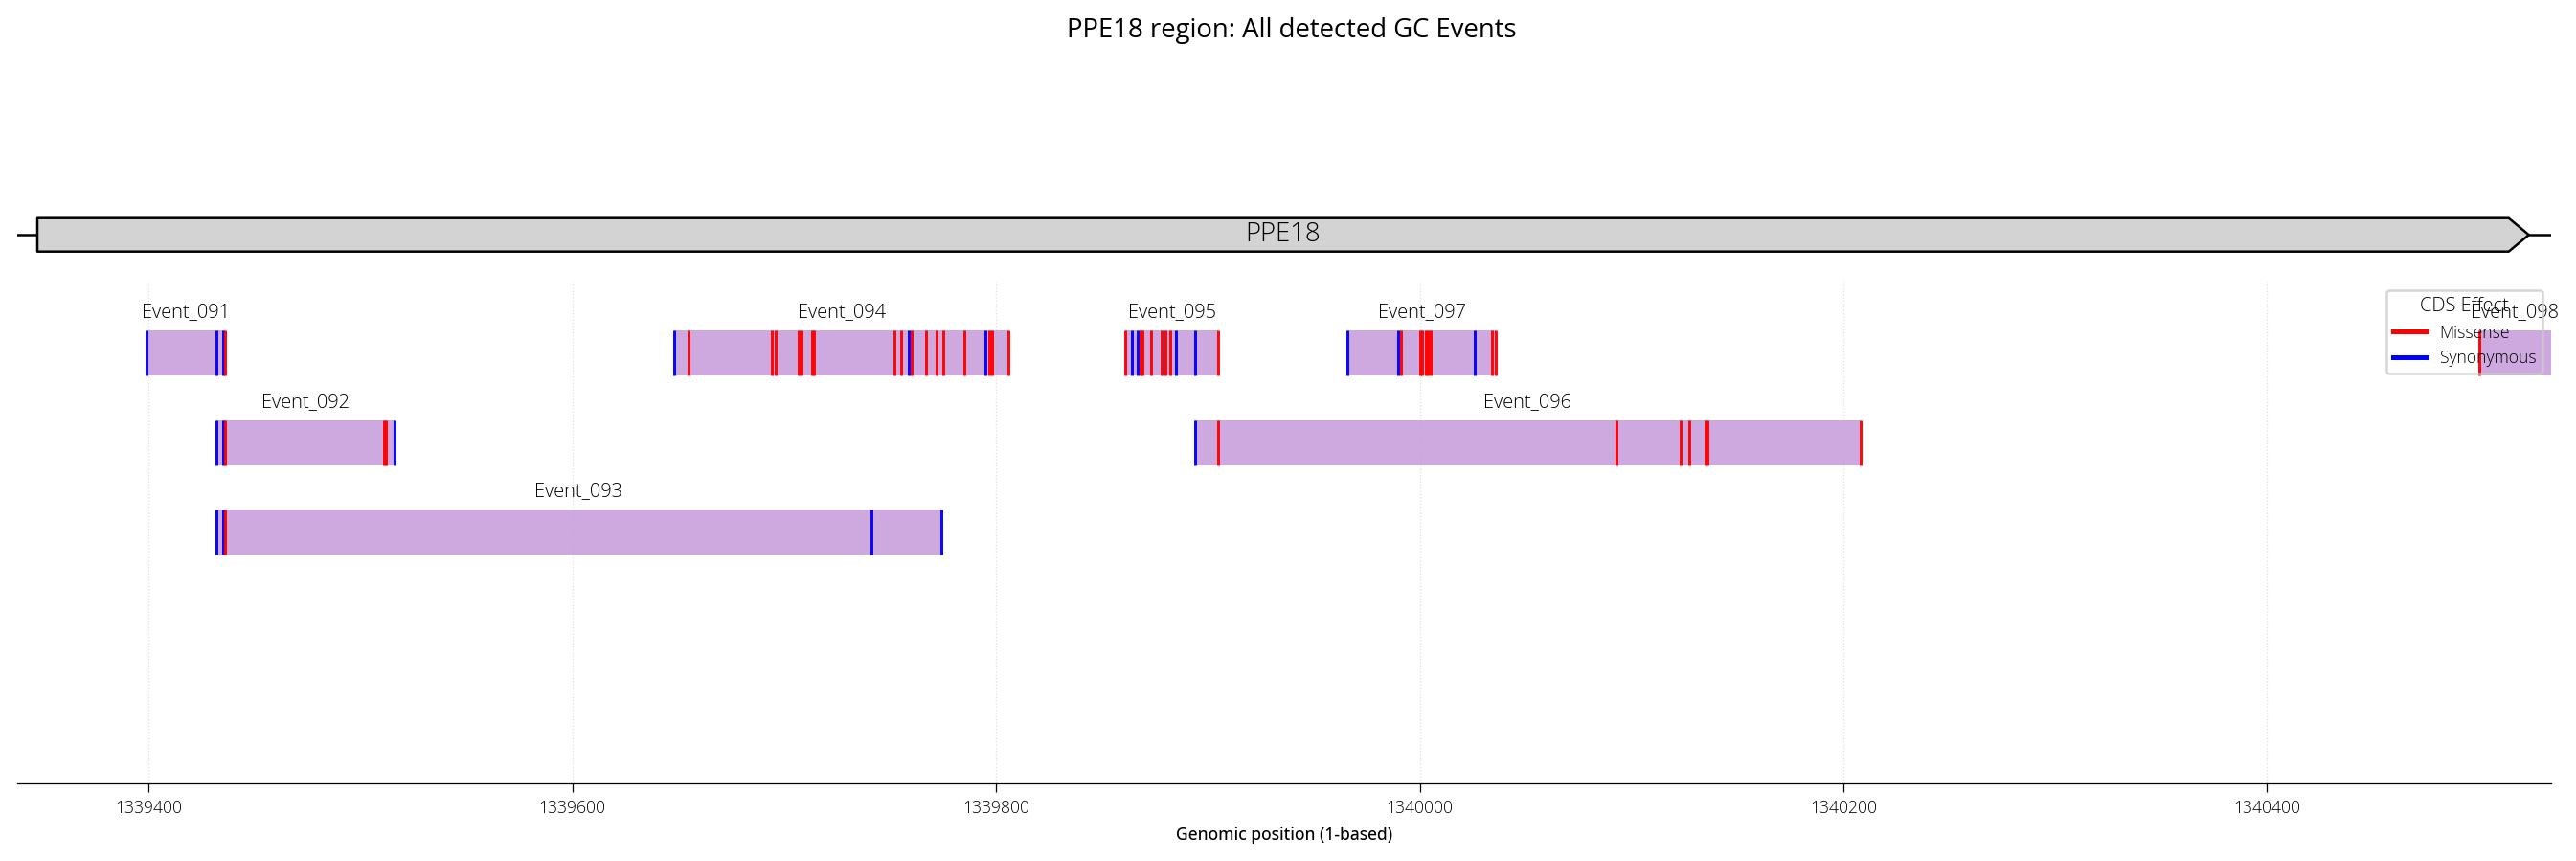

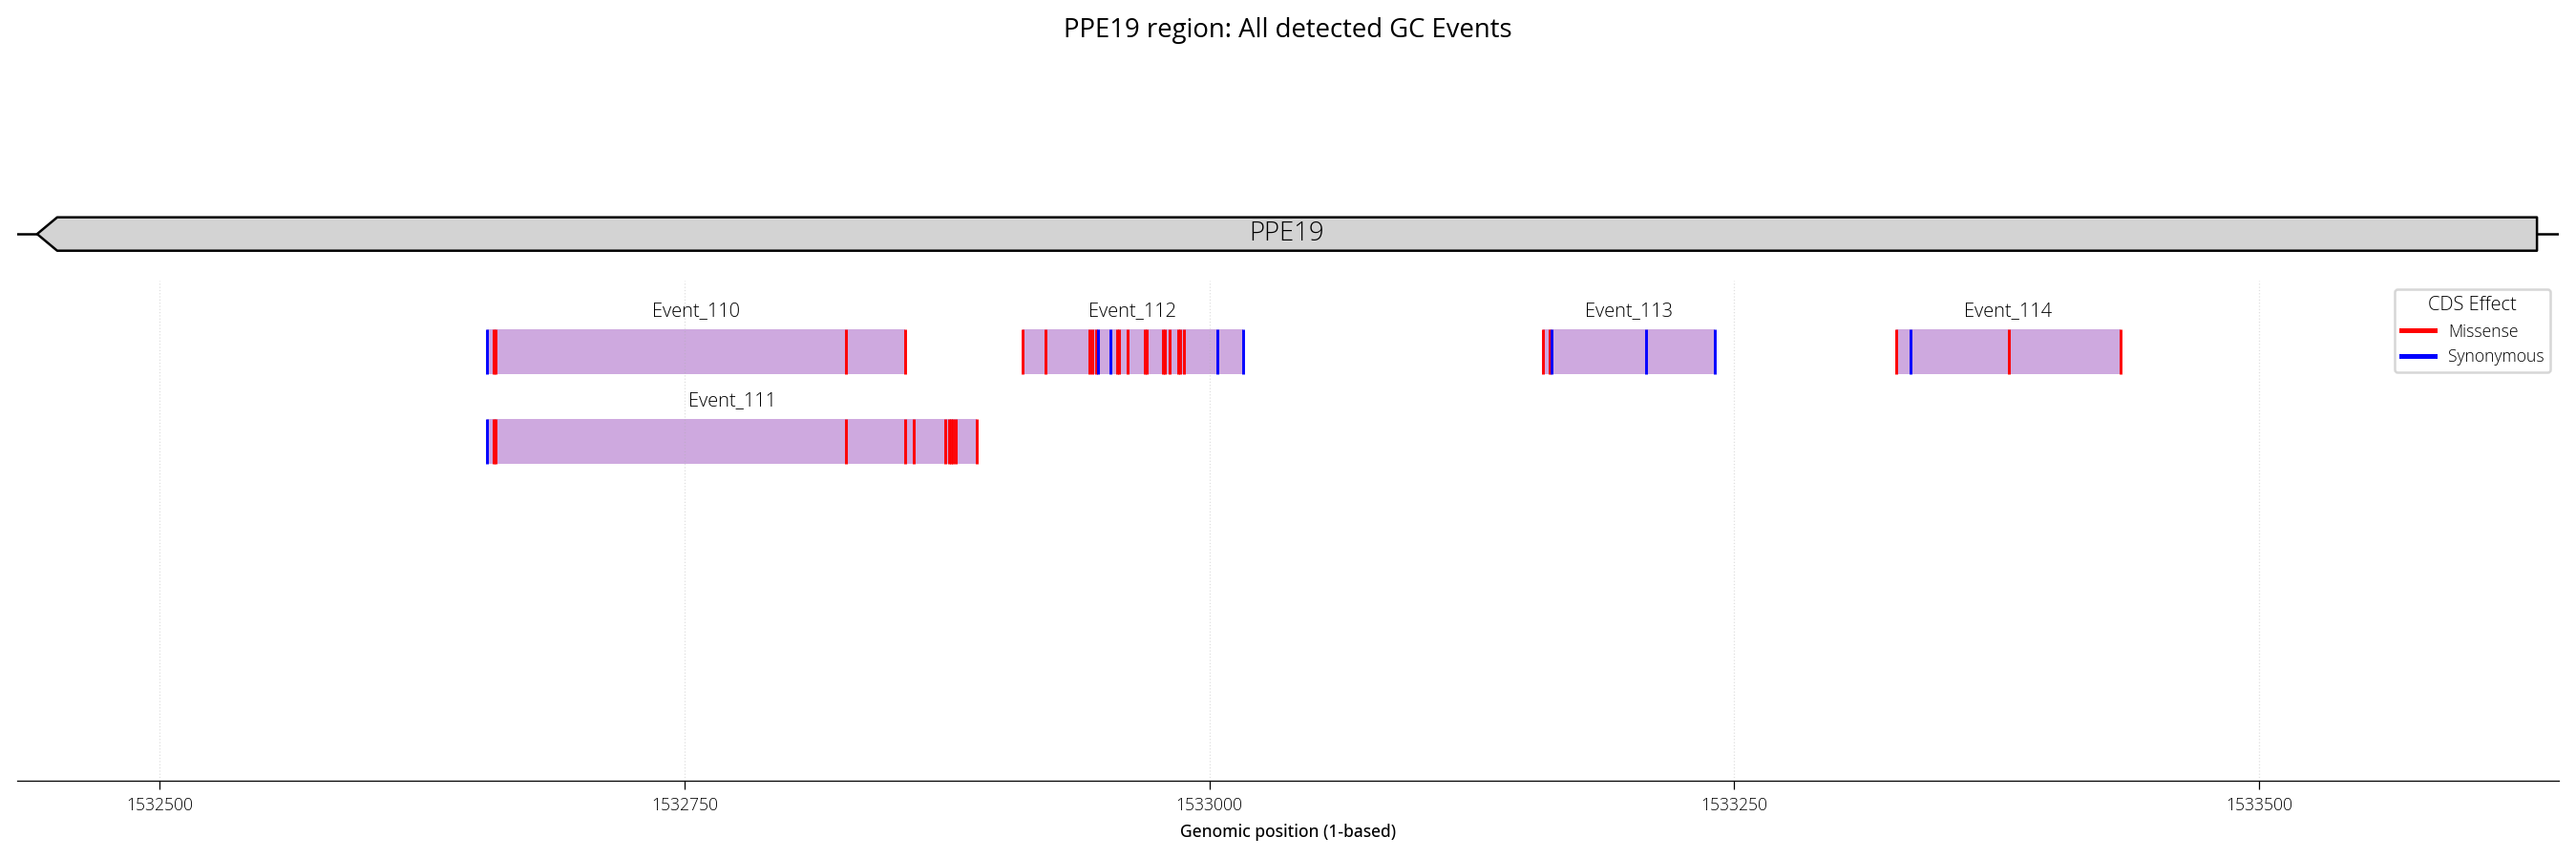

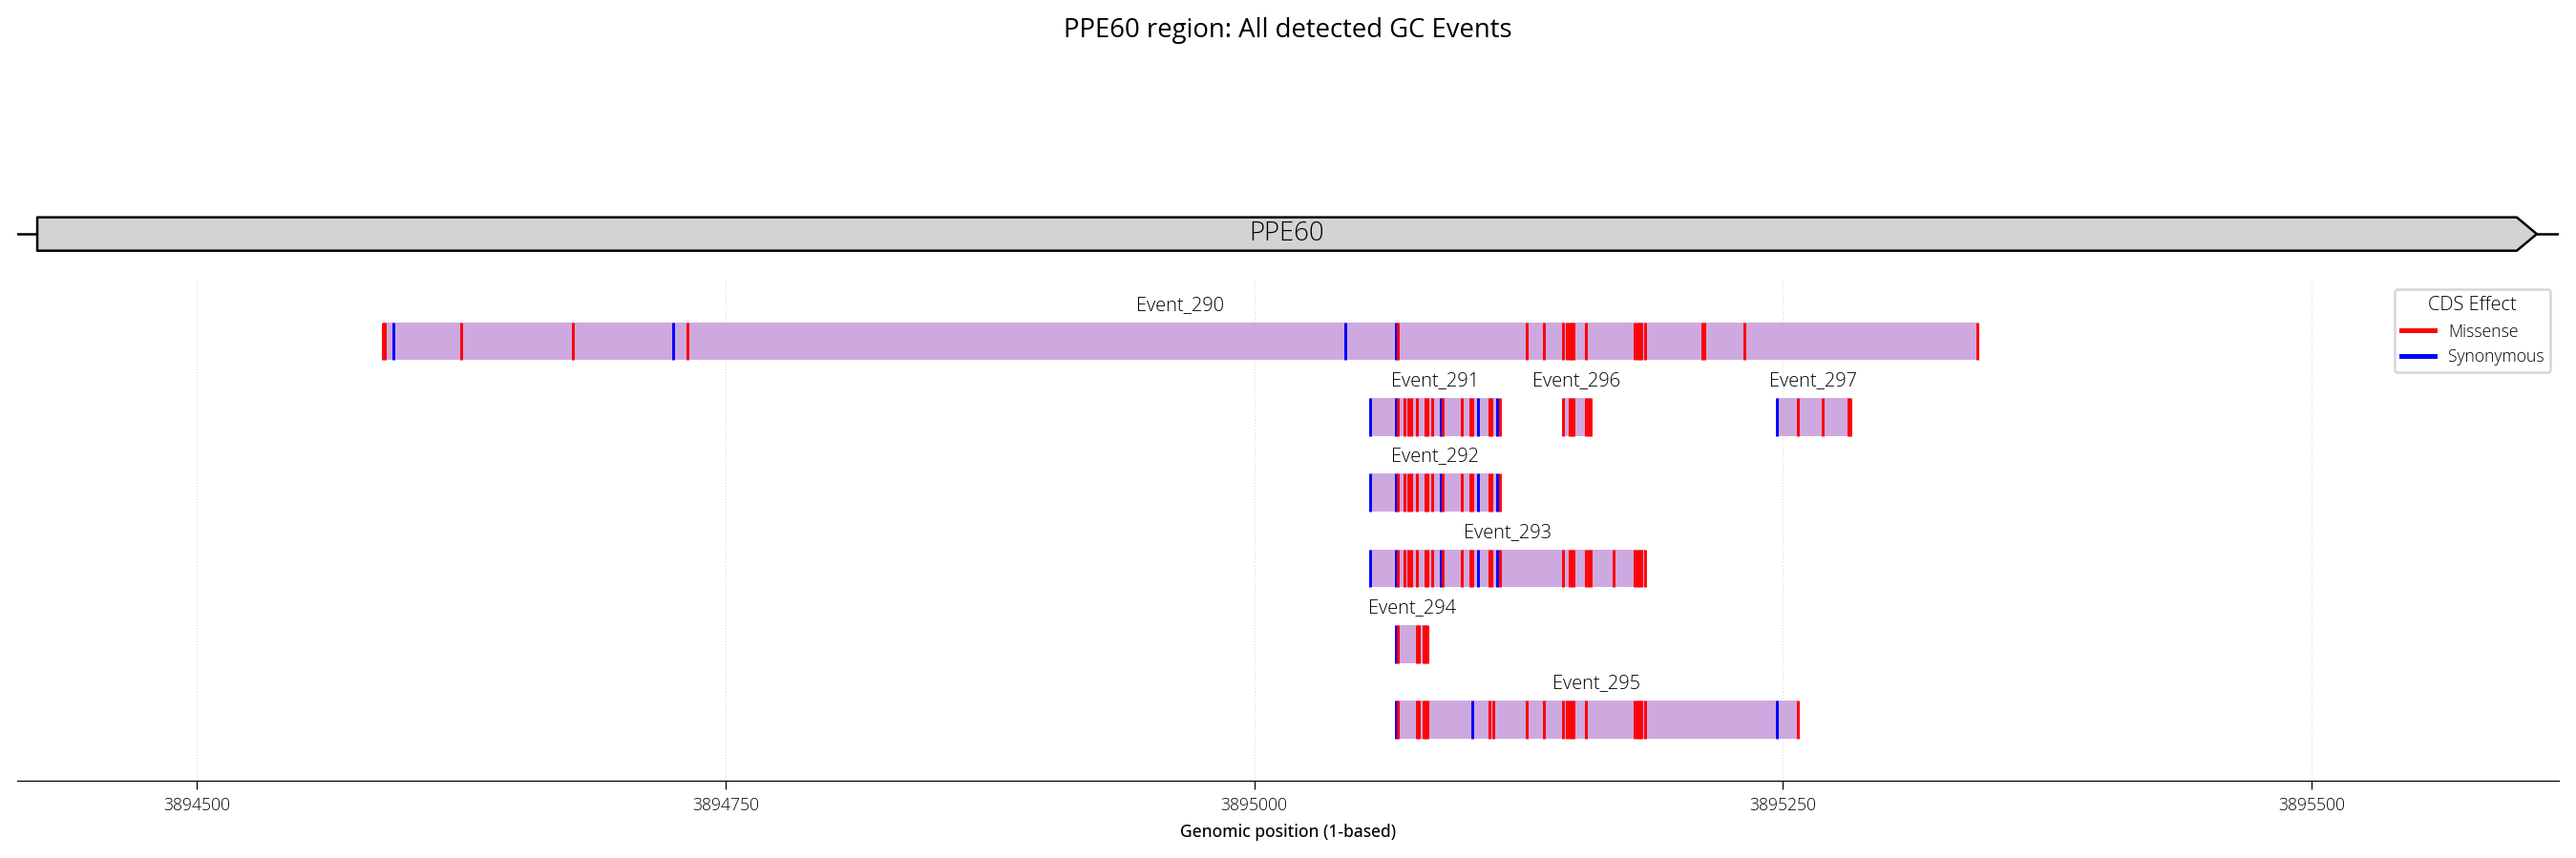

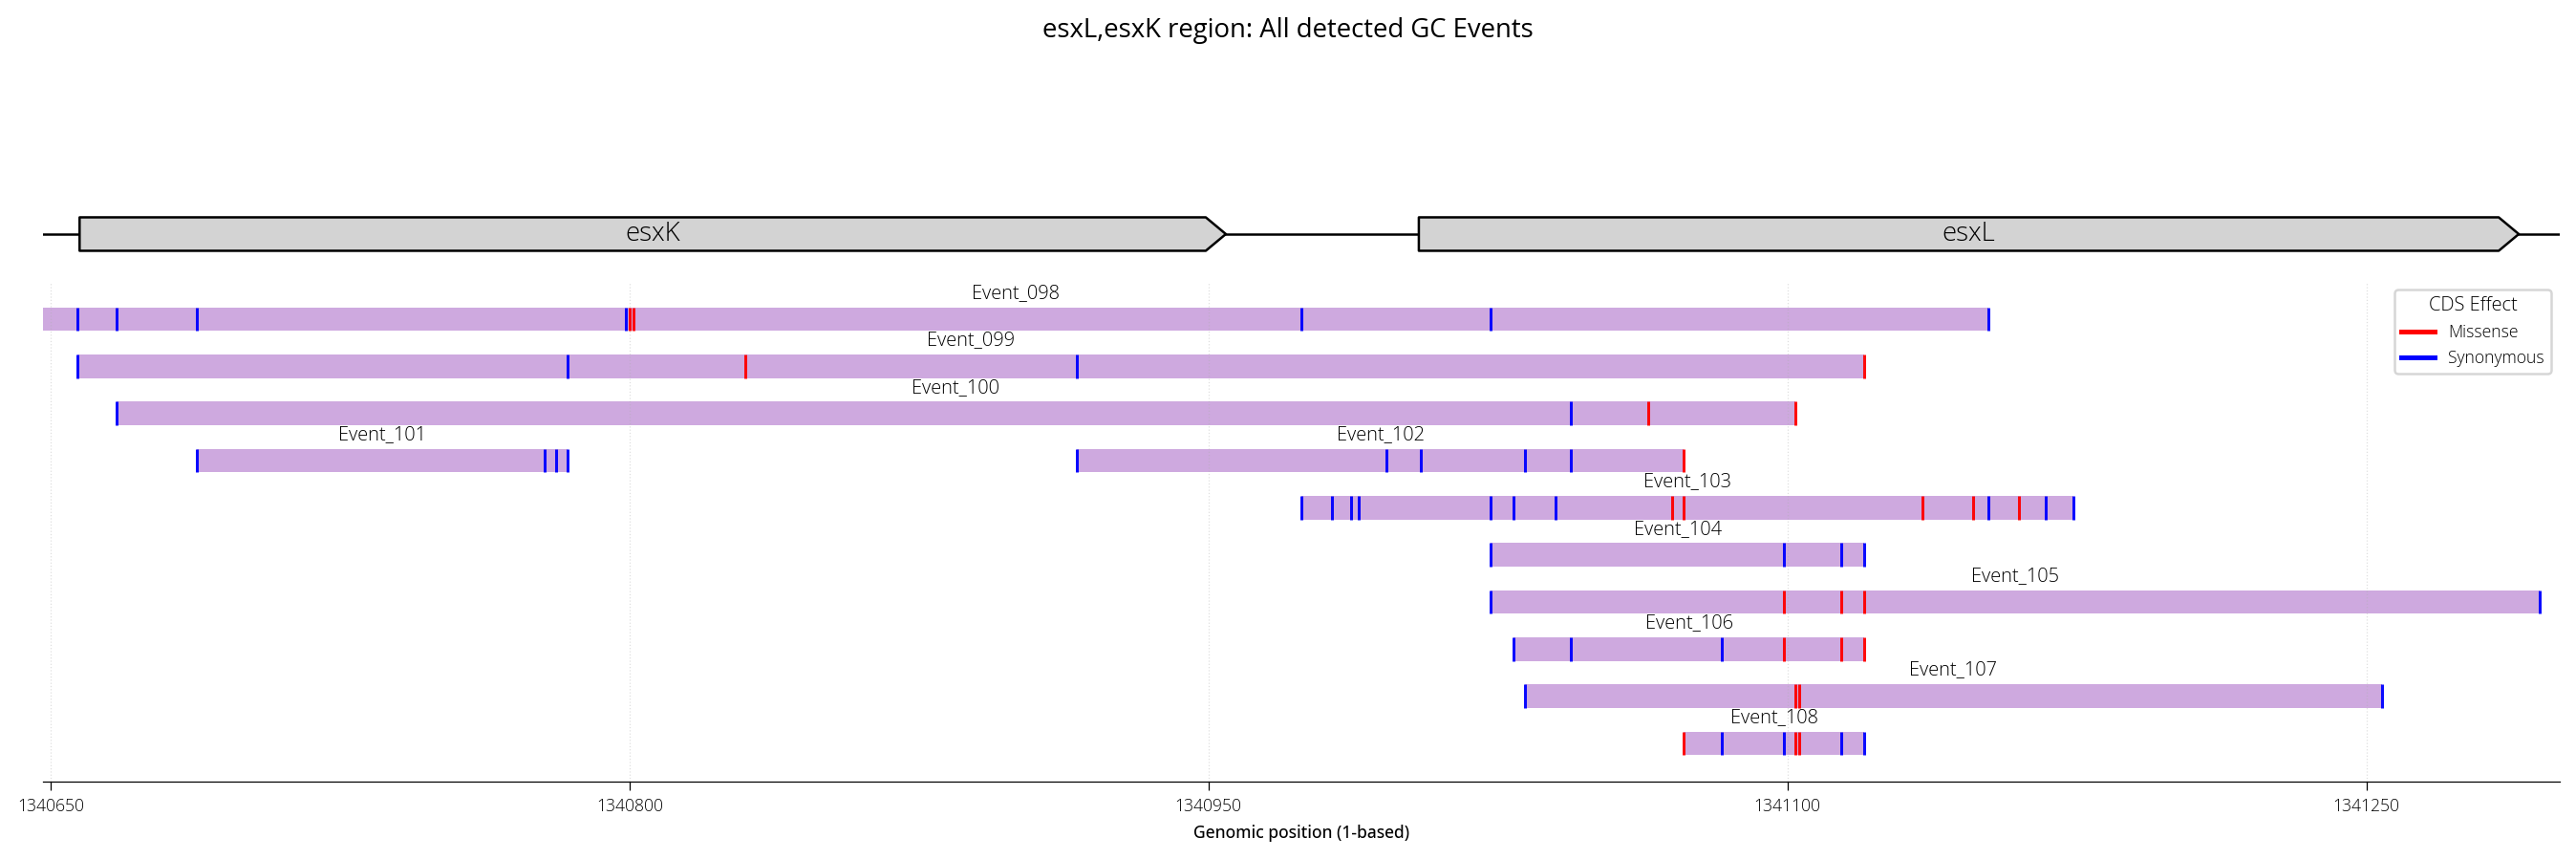

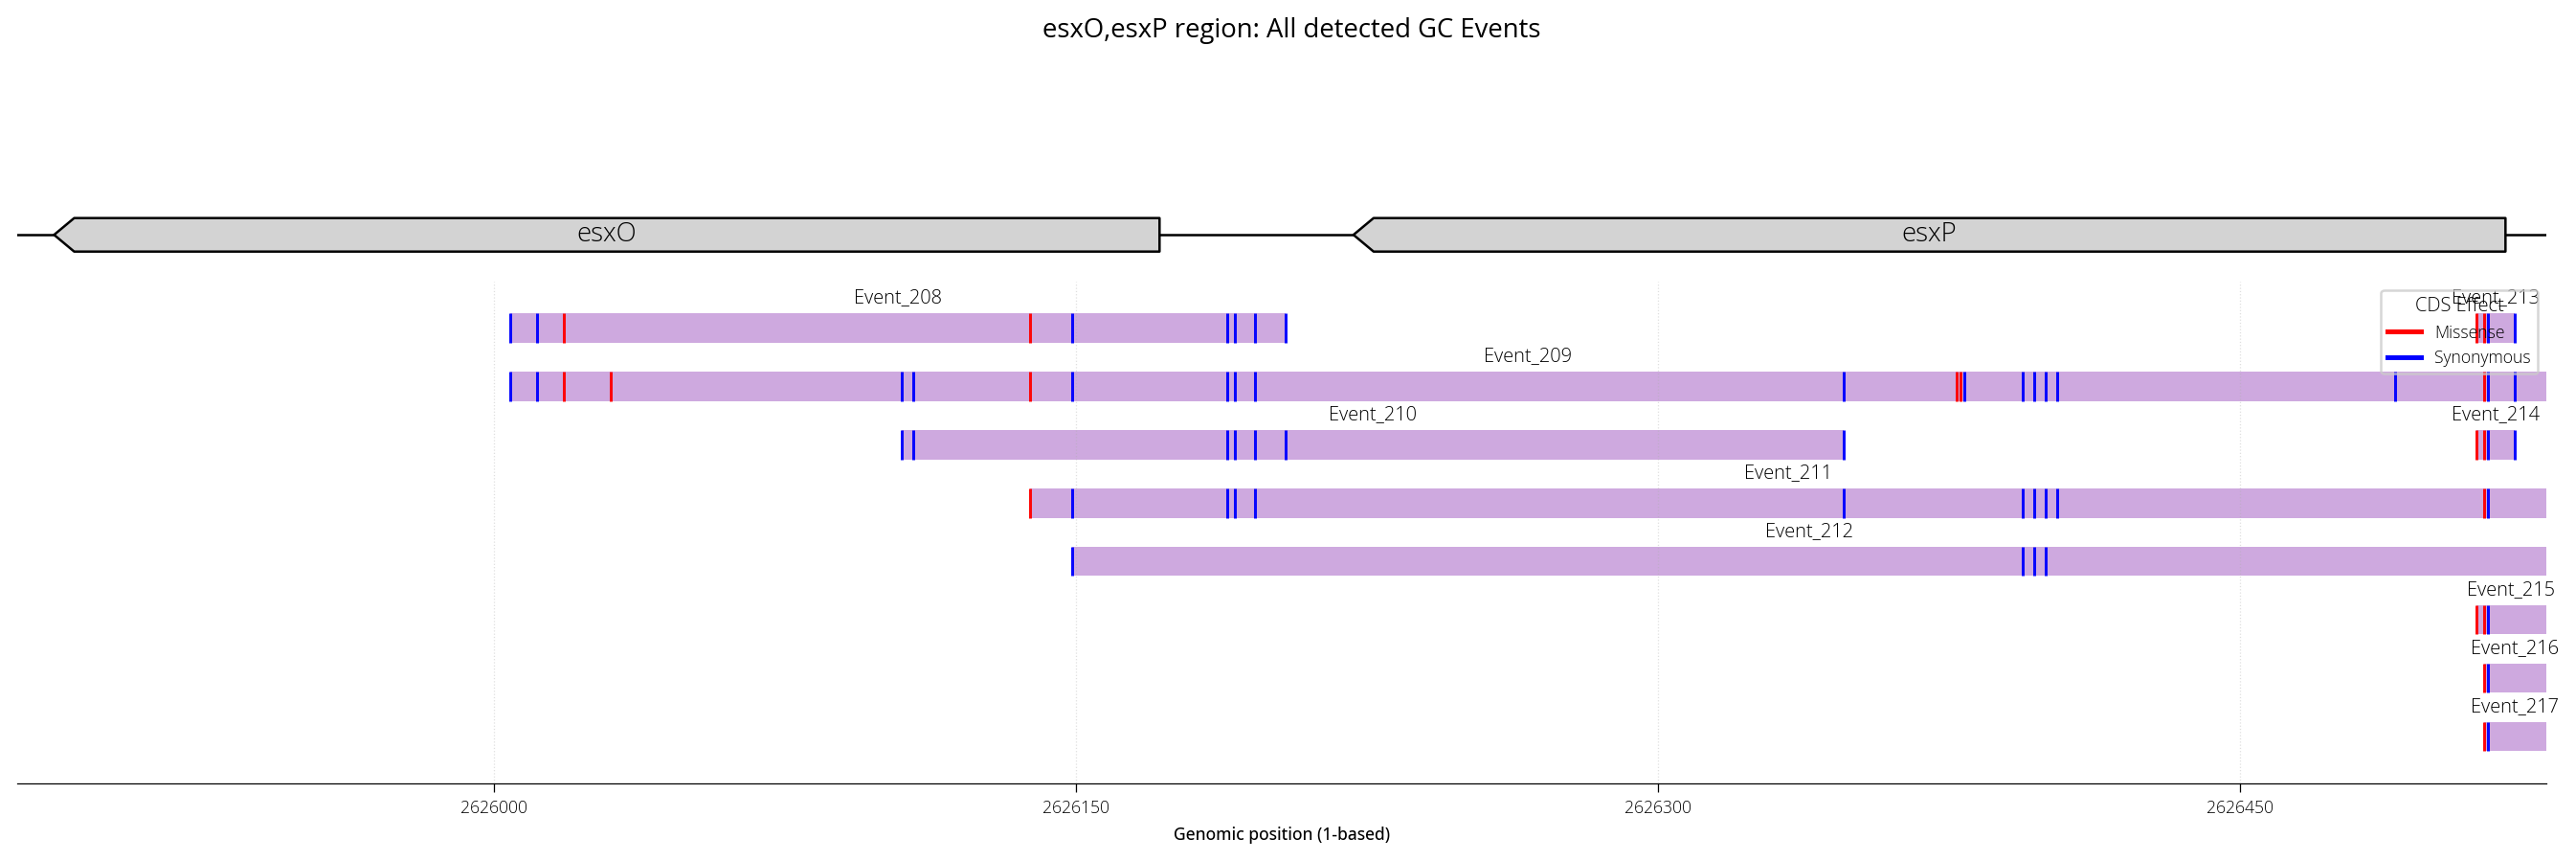

In [104]:
in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

input_Antigen_Symbols = ["PPE18", "PPE19", "PPE60",
                         "esxL,esxK", "esxO,esxP",]


for i_Symbol in input_Antigen_Symbols:

    i_Symbol_List = i_Symbol.split(",")
    i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF[  Genes_GCandMutFreqStats_DF["Symbol"].isin(i_Symbol_List) ]

    i_Gene_Start = i_Gene_MutInfo_DF["Start"].min()
    i_Gene_End = i_Gene_MutInfo_DF["End"].max()

    
    Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10
    
    i_Gene_InHHR = i_Gene_MutInfo_DF["HasHmRegion"].values[0]

    fig4, ax4, = plot_Anno_with_GCE_V3(Viz_Start = Viz_Start,
                                       Viz_End = Viz_End,
                                       in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
                                       pGCE_df = pGCE_DF,
                                       snps_df = Gub_SNPs_V2_DF,
                                       title = f"{i_Symbol} region: All detected GC Events",
                                       gce_min_rows = 5,
                                       )

    fig4.savefig(f"GeneViz_WiGCEs_Plots/{i_Symbol}.All.GCEs.V3.svg")
    
    fig4.show()



# Extras